 📅 Análisis de Procedencia del turismo — ¿De donde vienen los viajeros?

**Fuente de datos:** Encuesta de Ocupació Hotelera (EOH) — Instituto Nacional de Estadística (INE)  
---

 📌 ¿Qué se analiza en este notebook?

Este notebook responde a la pregunta de negocio desde la **dimensión temporal**: ¿Cual es el origen de los viajeros que nos visitan?

El análisis se divide en bloques:


> **Nota de contexto:** Este notebook forma parte de un análisis trifásico. El análisis de *temporalidad* (¿de dónde vienen?) y el de *pernoctaciones* (¿cuánto tiempo se quedan?) son tratados por otros analistas del equipo y se integrarán en la puesta en común final.


# 0.- Librerias

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración visual global
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

MESES_ES = {1:'Ene', 2:'Feb', 3:'Mar', 4:'Abr', 5:'May', 6:'Jun',
            7:'Jul', 8:'Ago', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dic'}
MESES_FULL = {1:'Enero', 2:'Febrero', 3:'Marzo', 4:'Abril', 5:'Mayo', 6:'Junio',
              7:'Julio', 8:'Agosto', 9:'Septiembre', 10:'Octubre', 11:'Noviembre', 12:'Diciembre'}

MIS_CIUDADES = [
    'Sevilla', 'Málaga', 'Palma', 'Barcelona',
    'Girona', 'Madrid', 'Ciutadella de Menorca', 'València'
]


print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.


# 1.- Importar datos

In [80]:
# Carga de los datasets relevantes para este análisis
df_residencias = pd.read_csv('2026_06_15_residencias_limpio.csv')   # Viajeros y pernoctaciones según país de residencia del viajero
df_ciudades = pd.read_csv('2026_06_15_ciudades_limpio.csv')       # Viajeros y pernoctaciones por ciudad turística

print(f"residencias: {df_residencias.shape[0]:,} filas | {df_residencias.shape[1]} columnas")
print(f"ciudades:    {df_ciudades.shape[0]:,} filas | {df_ciudades.shape[1]} columnas")


residencias: 3,840 filas | 7 columnas
ciudades:    33,120 filas | 9 columnas


In [81]:
# Revisión rápida de estructura — mostramos solo filas representativas (sin totales nacionales)
print("=== Estructura del dataset residencias  ===")
display(df_residencias.head(3))

print("\n=== Estructura del dataset ciudades ===")
display(df_ciudades.head(3))


=== Estructura del dataset residencias  ===


,RESIDENCIA/ORIGEN,Países,Viajeros y pernoctaciones,Periodo,Total,año,mes
0,Total,NaN,Viajero,2025M12,6937385.0,2025,12
1,Total,NaN,Viajero,2025M11,7413495.0,2025,11
2,Total,NaN,Viajero,2025M10,11041430.0,2025,10



=== Estructura del dataset ciudades ===


,Puntos turísticos,Viajeros y pernoctaciones,Residencia,Periodo,Total,año,mes,cod_postal_ciudad,nombre_ciudad
0,01059 Vitoria-Gasteiz,Viajero,Residentes en España,2025M12,23737.0,2025,12,1059,Vitoria-Gasteiz
1,01059 Vitoria-Gasteiz,Viajero,Residentes en España,2025M11,21544.0,2025,11,1059,Vitoria-Gasteiz
2,01059 Vitoria-Gasteiz,Viajero,Residentes en España,2025M10,24269.0,2025,10,1059,Vitoria-Gasteiz


In [5]:
# comprobacion de nulos
print("\n=== Dataset residencias — nulos ===")
print(df_residencias.isnull().sum())

print("\n=== Dataset ciudades — nulos ===")
print(df_ciudades.isnull().sum())



=== Dataset residencias — nulos ===
RESIDENCIA/ORIGEN              0
Países                       600
Viajeros y pernoctaciones      0
Periodo                        0
Total                        212
año                            0
mes                            0
dtype: int64

=== Dataset ciudades — nulos ===
Puntos turísticos               0
Viajeros y pernoctaciones       0
Residencia                      0
Periodo                         0
Total                        7654
año                             0
mes                             0
cod_postal_ciudad               0
nombre_ciudad                   0
dtype: int64


In [6]:
# Rango temporal y variables disponibles
print("=== Años disponibles COMUNES ===")
print(f"  residencias: {sorted(df_residencias['año'].unique())}")
print(f"  ciudades:    {sorted(df_ciudades['año'].unique())}\n")

print("=== RESIDENCIAS ===")
print(f"  RESIDENCIA/ORIGEN: {sorted(df_residencias['RESIDENCIA/ORIGEN'].unique())}")
# print(f"  residencias:    {(df_residencias['Países'].unique())}")
print(f"  Países:    {sorted(df_residencias['Países'].dropna().unique())}")
print(f"  Viajeros y pernoctaciones: {sorted(df_residencias['Viajeros y pernoctaciones'].unique())}\n")

print("=== CIUDADES ===")
print(f"  nombre_ciudad: {sorted(df_ciudades['nombre_ciudad'].unique())}")
print(f"  Viajeros y pernoctaciones: {sorted(df_ciudades['Viajeros y pernoctaciones'].unique())}")
print(f"  Residencia: {sorted(df_ciudades['Residencia'].unique())}")

=== Años disponibles COMUNES ===
  residencias: [2021, 2022, 2023, 2024, 2025]
  ciudades:    [2021, 2022, 2023, 2024, 2025]

=== RESIDENCIAS ===
  RESIDENCIA/ORIGEN: ['América (sin EEUU)', 'Asia (sin Japón)', 'Estados Unidos de América', 'Japón', 'Total']
  Países:    ['Alemania', 'Austria', 'Bélgica', 'Dinamarca', 'Finlandia', 'Francia', 'Grecia', 'Irlanda', 'Italia', 'Luxemburgo', 'Noruega', 'Otros Países Europeos', 'Países Bajos', 'Polonia', 'Portugal', 'Reino Unido', 'República Checa', 'Residentes en España', 'Residentes en el Extranjero', 'Resto de la U.E.', 'Resto del Mundo', 'Rusia', 'Suecia', 'Suiza', 'UE27_2020 sin España', 'UE28 sin España', 'África']
  Viajeros y pernoctaciones: ['Pernoctaciones', 'Viajero']

=== CIUDADES ===
  nombre_ciudad: ['Adeje', 'Alacant/Alicante', 'Albacete', 'Albarracín', 'Alcalá de Henares', 'Alcúdia', 'Algeciras', 'Almería', 'Almuñécar', 'Altea', 'Antequera', 'Antigua', 'Arcos de la Frontera', 'Arona', 'Badajoz', 'Baeza', 'Barcelona', 'Benalmáden

# 2.- Origen Nacional e internacional

## Cuantos viajeros en toda España

In [7]:
# Procedencia de los viajeros nacional o internacional por año

# Filtro por viajeros
df_viajeros = df_ciudades[df_ciudades['Viajeros y pernoctaciones'] == 'Viajero']

# agrupo por año y residencia
tabla = (
    df_viajeros
    .groupby(['año', 'Residencia'])['Total']
    .sum()
    .unstack(fill_value=0)
    .reset_index()    
)

# renombro la tabla para mejorar las etiquetas
tabla = tabla.rename(columns={
    'Residentes en España': 'Españoles',
    'Residentes en el Extranjero': 'Extranjeros'
})

# quitar decimales
tabla[['Españoles', 'Extranjeros']] = tabla[['Españoles', 'Extranjeros']].round(0).astype(int)

# Calculamos el total anual
tabla['Total'] = tabla['Españoles'] + tabla['Extranjeros']

# Ahora calculamos los porcentajes
tabla['% Españoles'] = (tabla['Españoles'] / tabla['Total'] * 100).round(1)
tabla['% Extranjeros'] = (tabla['Extranjeros'] / tabla['Total'] * 100).round(1)

print("\n=== Total viajeros que se reciben en España ===")
display(tabla)


=== Total viajeros que se reciben en España ===


Residencia,año,Españoles,Extranjeros,Total,% Españoles,% Extranjeros
0,2021,22265415,14136322,36401737,61.2,38.8
1,2022,29951490,34452440,64403930,46.5,53.5
2,2023,30816909,40017155,70834064,43.5,56.5
3,2024,32976543,48240919,81217462,40.6,59.4
4,2025,32681367,49775682,82457049,39.6,60.4


**Interpretación técnica:** 
 - Entre 2021 y 2025, España pasa de 36,4 millones de viajeros a 82,4 millones, lo que supone un crecimiento del 126% en solo cuatro años.
 - El crecimiento está impulsado principalmente por el mercado extranjero, que pasa de 14,1 M (2021) a 49,7 M (2025), un incremento del +252%.
 - El turismo nacional también crece, pero de forma mucho más moderada: de 22,3 M a 32,6 M (+46%).
 - El punto de inflexión se produce en 2022, cuando los extranjeros superan por primera vez a los nacionales (53,5% vs 46,5%).
 - Desde 2022, la proporción de extranjeros no deja de aumentar:
    - 2022 → 53,5%
    - 2023 → 56,5%
    - 2024 → 59,4%
    - 2025 → 60,4%
 - Esto indica una tendencia estructural, no un efecto puntual: el peso del turismo internacional crece año tras año.
 - El total nacional se mantiene relativamente estable entre 2023 y 2025, mientras que el extranjero sigue creciendo, lo que sugiere saturación o techo en el mercado doméstico. 

**Interpretación de negocio:** 
 - España se está convirtiendo en un destino cada vez más internacionalizado: en 2025, 6 de cada 10 viajeros ya son extranjeros.
 - El mercado nacional sigue siendo importante, pero ha dejado de ser el motor del crecimiento.
 - Para StaySpain, esto implica un cambio estratégico claro:
    - El crecimiento futuro vendrá del mercado internacional, no del nacional.
    - Las inversiones en marketing, partnerships y distribución deben priorizar Reino Unido, Alemania, Francia, Italia y Países Bajos, que son los países que más crecen (según tus tablas previas).
 - El hecho de que el turismo nacional esté estable sugiere:
    - Es un mercado fiel pero limitado.
    - No generará grandes incrementos de volumen, pero sí puede aportar estabilidad en temporada baja.
 - La aceleración del turismo extranjero implica:
    - Mayor gasto medio por viajero (oportunidad para revenue).
    - Mayor dependencia de mercados externos (riesgo ante shocks internacionales).
    - Necesidad de reforzar idiomas, UX internacional, métodos de pago globales y campañas segmentadas.
 - El salto de 2024 a 2025 (+1,2 M extranjeros adicionales) indica que España sigue ganando cuota en el turismo europeo, lo que StaySpain puede aprovechar con:
    - Campañas de captación en origen (UK, DE, FR).
    - Paquetes de larga estancia (los extranjeros tienden a estancias más largas).
    - Optimización de precios en verano, donde la elasticidad es menor.


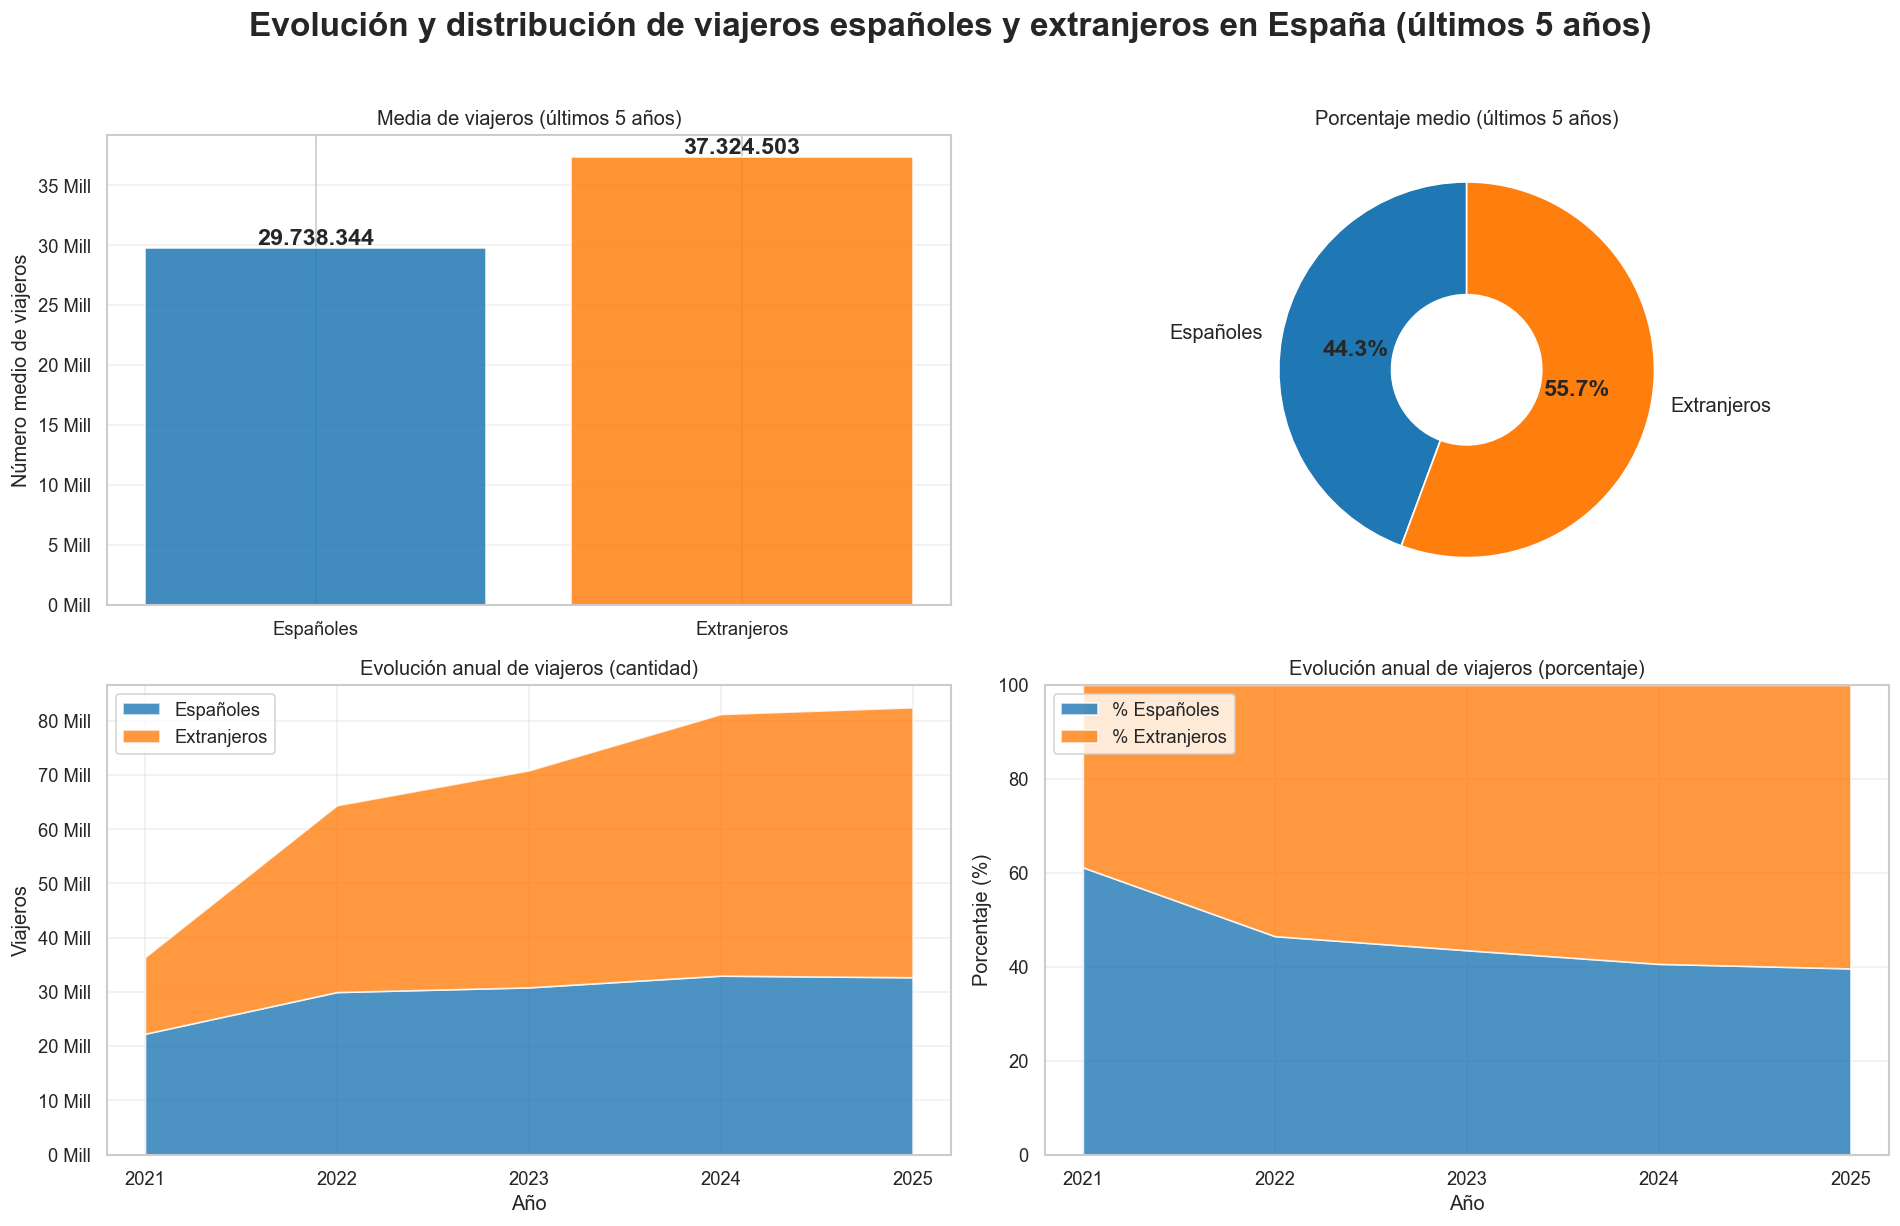

In [8]:

# --- Formateador para mostrar valores en millones ---
def millones(x, pos):
    return f"{x/1_000_000:.0f} Mill"


# --- Cálculo de medias y porcentajes ---
media_5años = tabla[['Españoles', 'Extranjeros']].mean()
total_medio = media_5años.sum()

porcentaje_españoles = media_5años['Españoles'] / total_medio * 100
porcentaje_extranjeros = media_5años['Extranjeros'] / total_medio * 100

# --- Cálculo de porcentajes por año ---
tabla['% Españoles'] = tabla['Españoles'] / (tabla['Españoles'] + tabla['Extranjeros']) * 100
tabla['% Extranjeros'] = tabla['Extranjeros'] / (tabla['Españoles'] + tabla['Extranjeros']) * 100

# --- Crear figura con 4 subplots ---
fig, axes = plt.subplots(2, 2, figsize=(16,10))

# Título general
fig.suptitle(
    "Evolución y distribución de viajeros españoles y extranjeros en España (últimos 5 años)",
    fontsize=20,
    fontweight='bold',
    y=1.02
)

# ============================================================
# 1) BARRAS — Media de viajeros
# ============================================================
axes[0,0].bar(
    ['Españoles', 'Extranjeros'],
    media_5años.values.astype(int),
    color=['#1f77b4', '#ff7f0e'],
    alpha=0.85
)

axes[0,0].set_title('Media de viajeros (últimos 5 años)')
axes[0,0].set_ylabel('Número medio de viajeros')
axes[0,0].grid(axis='y', alpha=0.3)

# Formato en millones
axes[0,0].yaxis.set_major_formatter(FuncFormatter(millones))

# Etiquetas encima de cada barra
for i, v in enumerate(media_5años.values.astype(int)):
    axes[0,0].text(i, v, f"{v:,}".replace(",", "."), ha='center', va='bottom',
                   fontsize=14, fontweight='bold')

# ============================================================
# 2) DONUT — Porcentajes medios
# ============================================================
wedges, texts, autotexts = axes[0,1].pie(
    [porcentaje_españoles, porcentaje_extranjeros],
    labels=['Españoles', 'Extranjeros'],
    autopct='%1.1f%%',
    colors=['#1f77b4', '#ff7f0e'],
    startangle=90,
    wedgeprops={'width': 0.6}
)

for autotext in autotexts:
    autotext.set_fontsize(14)
    autotext.set_weight('bold')

for text in texts:
    text.set_fontsize(12)

axes[0,1].set_title('Porcentaje medio (últimos 5 años)')

# ============================================================
# 3) EVOLUCIÓN EN CANTIDAD — Área apilada
# ============================================================
axes[1,0].stackplot(
    tabla['año'],
    tabla['Españoles'],
    tabla['Extranjeros'],
    labels=['Españoles', 'Extranjeros'],
    colors=['#1f77b4', '#ff7f0e'],
    alpha=0.8
)

axes[1,0].set_title('Evolución anual de viajeros (cantidad)')
axes[1,0].set_xlabel('Año')
axes[1,0].set_ylabel('Viajeros')
axes[1,0].legend(loc='upper left')
axes[1,0].grid(alpha=0.3)

# Formato en millones
axes[1,0].yaxis.set_major_formatter(FuncFormatter(millones))

axes[1,0].set_xticks(tabla['año'])
axes[1,0].set_xticklabels(tabla['año'].astype(int))

# ============================================================
# 4) EVOLUCIÓN EN PORCENTAJE — Área apilada
# ============================================================
axes[1,1].stackplot(
    tabla['año'],
    tabla['% Españoles'],
    tabla['% Extranjeros'],
    labels=['% Españoles', '% Extranjeros'],
    colors=['#1f77b4', '#ff7f0e'],
    alpha=0.8
)

axes[1,1].set_title('Evolución anual de viajeros (porcentaje)')
axes[1,1].set_xlabel('Año')
axes[1,1].set_ylabel('Porcentaje (%)')
axes[1,1].legend(loc='upper left')
axes[1,1].set_ylim(0, 100)
axes[1,1].grid(alpha=0.3)

axes[1,1].set_xticks(tabla['año'])
axes[1,1].set_xticklabels(tabla['año'].astype(int))

plt.tight_layout()
plt.show()


**Interpretación técnica:** La evolución conjunta de viajeros españoles y extranjeros en los últimos cinco años muestra un cambio estructural en la composición del turismo que recibe España. La media anual refleja que los extranjeros (37,3 M) superan de forma consistente a los españoles (29,7 M), lo que se confirma también en el reparto porcentual medio (55,7% vs 44,3%).
En la serie anual se observa un crecimiento sostenido en ambos segmentos, pero con una aceleración mucho mayor en el turismo internacional, que pasa de 14,1 M en 2021 a 49,7 M en 2025. El punto de inflexión se produce en 2022, cuando los extranjeros superan por primera vez a los nacionales y mantienen esa ventaja en los años siguientes.
La evolución porcentual refuerza esta tendencia: la cuota extranjera aumenta de forma continua desde el 38,8% hasta el 60,4%, mientras que la nacional desciende en la misma proporción. No hay oscilaciones relevantes ni retrocesos, lo que indica un patrón estable y consolidado.

**Interpretación de negocio:** España se ha convertido en un destino claramente internacionalizado: en 2025, seis de cada diez viajeros ya proceden del extranjero. Esto implica que el crecimiento del sector turístico está siendo impulsado principalmente por mercados internacionales, mientras que el turismo nacional actúa como base estable pero con menor capacidad de expansión.
Para StaySpain, esta tendencia abre oportunidades claras: reforzar campañas en mercados emisores clave (Reino Unido, Alemania, Francia, Italia y Países Bajos), optimizar precios en temporada alta —donde la demanda extranjera es menos sensible al precio— y potenciar productos de larga estancia y mayor gasto medio.
El turismo nacional sigue siendo relevante para sostener la ocupación en temporada baja, por lo que conviene mantener estrategias específicas para escapadas, puentes y city breaks. La combinación de ambos segmentos permite una estrategia dual: captación internacional en verano y puentes largos, y activación del mercado doméstico en invierno y meses valle.


## Cuantos recibimos en mis ciudades

In [9]:
# Filtrar solo viajeros que van MIS_CIUDADES
df_viajeros = df_ciudades[
    (df_ciudades['Viajeros y pernoctaciones'] == 'Viajero') &
    (df_ciudades['nombre_ciudad'].isin(MIS_CIUDADES))
]

# Agrupoar por año y residencia
tabla_ciudades = (
    df_viajeros
    .groupby(['año', 'Residencia'])['Total']
    .sum()
    .unstack(fill_value=0)
    .reset_index()
)

# Renombrar para que quede la etiqueta más clara
tabla_ciudades = tabla_ciudades.rename(columns={
    'Residentes en España': 'Españoles',
    'Residentes en el Extranjero': 'Extranjeros'
})


tabla_ciudades['Total'] = tabla_ciudades['Españoles'] + tabla_ciudades['Extranjeros']
tabla_ciudades['% Españoles'] = (tabla_ciudades['Españoles'] / tabla_ciudades['Total'] * 100).round(1)
tabla_ciudades['% Extranjeros'] = (tabla_ciudades['Extranjeros'] / tabla_ciudades['Total'] * 100).round(1)


# quitar decimales
tabla_ciudades[['Españoles', 'Extranjeros', 'Total']] = (
    tabla_ciudades[['Españoles', 'Extranjeros', 'Total']]
    .round(0)
    .astype(int)
)

print("\n=== Total viajeros que recibimos solo en nuestras ciudades ===")
display(tabla_ciudades)


=== Total viajeros que recibimos solo en nuestras ciudades ===


Residencia,año,Españoles,Extranjeros,Total,% Españoles,% Extranjeros
0,2021,6367135,6174029,12541164,50.8,49.2
1,2022,9169638,15070730,24240368,37.8,62.2
2,2023,9466927,17764976,27231903,34.8,65.2
3,2024,9324350,19522062,28846412,32.3,67.7
4,2025,9105608,20683710,29789318,30.6,69.4


**Interpretación técnica:** Los datos muestran la evolución anual de los viajeros que llegan exclusivamente a nuestras ciudades entre 2021 y 2025. En 2021 la distribución entre españoles y extranjeros es prácticamente equilibrada (50,8% vs 49,2%), pero a partir de 2022 se observa un cambio estructural: los viajeros extranjeros pasan a ser mayoría y su peso aumenta de forma sostenida hasta alcanzar el 69,4% en 2025.
En términos absolutos, el turismo nacional crece entre 2021 y 2023, pero se estabiliza y comienza a descender ligeramente en 2024 y 2025. En contraste, el turismo extranjero mantiene un crecimiento continuo, pasando de 6,1 millones en 2021 a más de 20,6 millones en 2025.
El ratio implícito muestra una divergencia clara: mientras el volumen nacional se mantiene en torno a los 9 millones, el internacional prácticamente triplica su tamaño en cinco años. Esto indica una reconfiguración de la demanda en nuestras ciudades, con un peso creciente del mercado internacional

**Interpretación de negocio:** Nuestras ciudades están experimentando una transformación profunda en su perfil turístico: han pasado de un equilibrio entre mercado nacional e internacional a convertirse en destinos claramente dominados por viajeros extranjeros. En 2025, siete de cada diez visitantes ya proceden del extranjero, lo que implica que el crecimiento y la oportunidad de negocio se concentran en mercados internacionales.
Para StaySpain, esto significa que la estrategia debe orientarse a reforzar la captación en países emisores clave, optimizar precios en temporada alta —donde la demanda extranjera es menos sensible al precio— y potenciar productos adaptados a estancias más largas y de mayor gasto medio.
El turismo nacional sigue siendo relevante, pero su estabilización indica que su papel será principalmente el de sostener la ocupación en meses valle, no el de impulsar el crecimiento. La estrategia óptima es dual: campañas internacionales agresivas en primavera y verano, y activación del mercado doméstico en otoño e invierno para mantener la ocupación y estabilizar ingresos.


In [10]:
df_viajeros['nombre_ciudad'].unique()

array(['Ciutadella de Menorca', 'Palma', 'Barcelona', 'Girona', 'Madrid',
       'Málaga', 'Sevilla', 'València'], dtype=object)

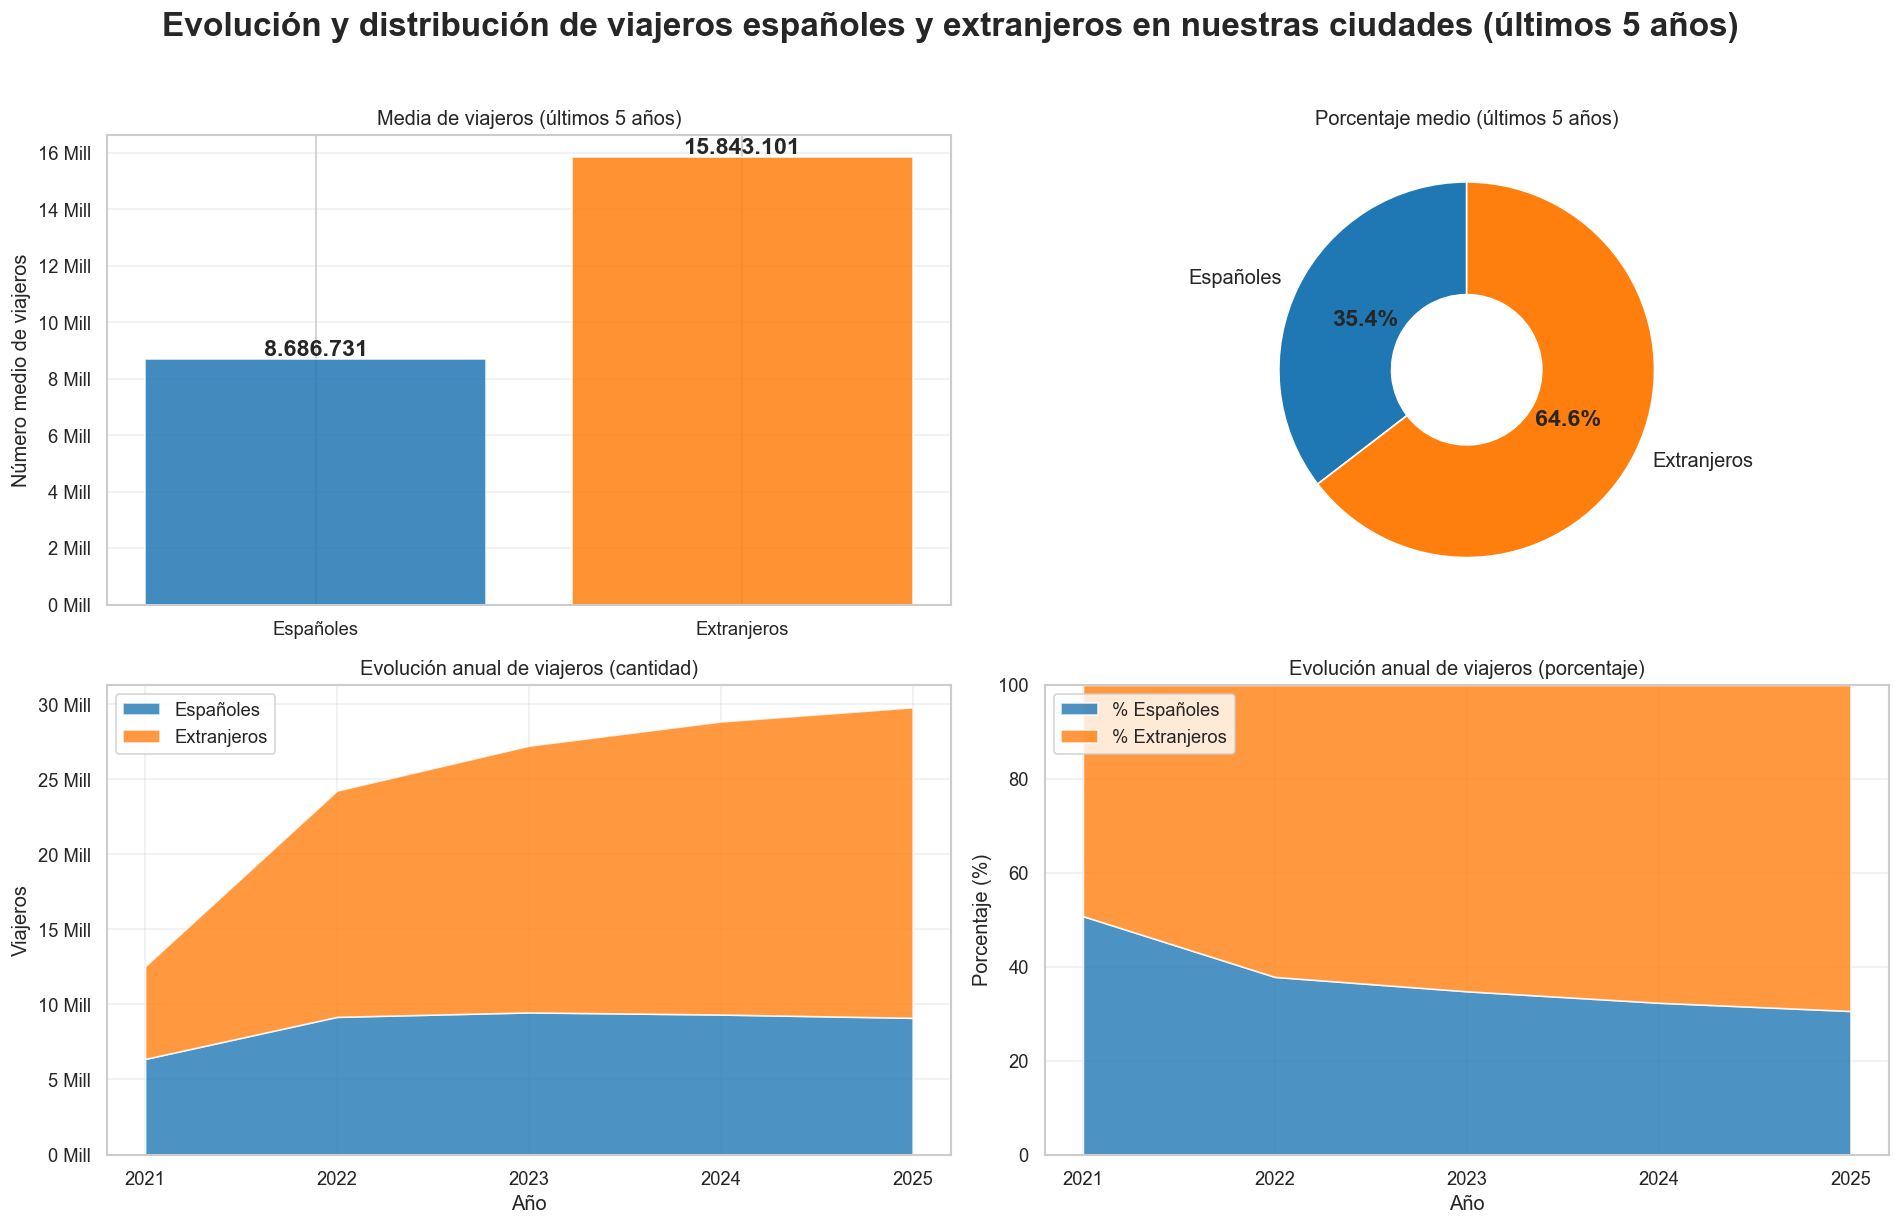

In [11]:


# --- Formateador para mostrar valores en millones ---
def millones(x, pos):
    return f"{x/1_000_000:.0f} Mill"


# --- Cálculo de medias y porcentajes SOLO para nuestras ciudades ---
media_5años = tabla_ciudades[['Españoles', 'Extranjeros']].mean()
total_medio = media_5años.sum()

porcentaje_españoles = media_5años['Españoles'] / total_medio * 100
porcentaje_extranjeros = media_5años['Extranjeros'] / total_medio * 100

# --- Cálculo de porcentajes por año ---
tabla_ciudades['% Españoles'] = tabla_ciudades['Españoles'] / tabla_ciudades['Total'] * 100
tabla_ciudades['% Extranjeros'] = tabla_ciudades['Extranjeros'] / tabla_ciudades['Total'] * 100

# --- Crear figura con 4 subplots ---
fig, axes = plt.subplots(2, 2, figsize=(16,10))

# Título general
fig.suptitle(
    "Evolución y distribución de viajeros españoles y extranjeros en nuestras ciudades (últimos 5 años)",
    fontsize=20,
    fontweight='bold',
    y=1.02
)

# ============================================================
# 1) BARRAS — Media de viajeros
# ============================================================
axes[0,0].bar(
    ['Españoles', 'Extranjeros'],
    media_5años.values.astype(int),
    color=['#1f77b4', '#ff7f0e'],
    alpha=0.85
)

axes[0,0].set_title('Media de viajeros (últimos 5 años)')
axes[0,0].set_ylabel('Número medio de viajeros')
axes[0,0].grid(axis='y', alpha=0.3)

# Formato en millones
axes[0,0].yaxis.set_major_formatter(FuncFormatter(millones))

# Etiquetas encima de cada barra
for i, v in enumerate(media_5años.values.astype(int)):
    axes[0,0].text(i, v, f"{v:,}".replace(",", "."), ha='center', va='bottom',
                   fontsize=14, fontweight='bold')

# ============================================================
# 2) DONUT — Porcentajes medios
# ============================================================
wedges, texts, autotexts = axes[0,1].pie(
    [porcentaje_españoles, porcentaje_extranjeros],
    labels=['Españoles', 'Extranjeros'],
    autopct='%1.1f%%',
    colors=['#1f77b4', '#ff7f0e'],
    startangle=90,
    wedgeprops={'width': 0.6}
)

for autotext in autotexts:
    autotext.set_fontsize(14)
    autotext.set_weight('bold')

for text in texts:
    text.set_fontsize(12)

axes[0,1].set_title('Porcentaje medio (últimos 5 años)')

# ============================================================
# 3) EVOLUCIÓN EN CANTIDAD — Área apilada
# ============================================================
axes[1,0].stackplot(
    tabla_ciudades['año'],
    tabla_ciudades['Españoles'],
    tabla_ciudades['Extranjeros'],
    labels=['Españoles', 'Extranjeros'],
    colors=['#1f77b4', '#ff7f0e'],
    alpha=0.8
)

axes[1,0].set_title('Evolución anual de viajeros (cantidad)')
axes[1,0].set_xlabel('Año')
axes[1,0].set_ylabel('Viajeros')
axes[1,0].legend(loc='upper left')
axes[1,0].grid(alpha=0.3)

# Formato en millones
axes[1,0].yaxis.set_major_formatter(FuncFormatter(millones))

axes[1,0].set_xticks(tabla_ciudades['año'])
axes[1,0].set_xticklabels(tabla_ciudades['año'].astype(int))

# ============================================================
# 4) EVOLUCIÓN EN PORCENTAJE — Área apilada
# ============================================================
axes[1,1].stackplot(
    tabla_ciudades['año'],
    tabla_ciudades['% Españoles'],
    tabla_ciudades['% Extranjeros'],
    labels=['% Españoles', '% Extranjeros'],
    colors=['#1f77b4', '#ff7f0e'],
    alpha=0.8
)

axes[1,1].set_title('Evolución anual de viajeros (porcentaje)')
axes[1,1].set_xlabel('Año')
axes[1,1].set_ylabel('Porcentaje (%)')
axes[1,1].legend(loc='upper left')
axes[1,1].set_ylim(0, 100)
axes[1,1].grid(alpha=0.3)

axes[1,1].set_xticks(tabla_ciudades['año'])
axes[1,1].set_xticklabels(tabla_ciudades['año'].astype(int))

plt.tight_layout()
plt.show()


**Interpretación técnica:** Las gráficas muestran la evolución y distribución de los viajeros españoles y extranjeros que visitan nuestras ciudades durante los últimos cinco años. La media anual evidencia una diferencia estructural: los extranjeros (15,8 M) duplican prácticamente a los españoles (8,7 M). Esta relación se refleja también en el porcentaje medio, donde los extranjeros representan el 64,6% del total.
La evolución anual confirma un crecimiento sostenido en ambos segmentos, pero con una aceleración mucho mayor en el turismo internacional, que pasa de 6,1 M en 2021 a más de 20,6 M en 2025. El turismo nacional crece hasta 2023, pero se estabiliza y comienza a descender ligeramente en 2024 y 2025.
La evolución porcentual muestra una tendencia clara: la cuota extranjera aumenta de forma continua desde el 49,2% hasta el 69,4%, mientras que la nacional desciende en la misma proporción. No se observan retrocesos ni oscilaciones relevantes, lo que indica un cambio estructural en la composición del turismo en nuestras ciudades.

**Interpretación de negocio:** Nuestras ciudades se han consolidado como destinos claramente orientados al turismo internacional. En 2025, casi siete de cada diez viajeros son extranjeros, lo que convierte al mercado internacional en el principal motor de crecimiento. Esto implica que las estrategias de captación, pricing y producto deben priorizar a los mercados emisores clave, reforzando campañas en origen y adaptando la oferta a estancias más largas y de mayor gasto medio.
El turismo nacional sigue siendo relevante, pero su estabilización indica que su papel será principalmente el de sostener la ocupación en temporada baja. Para StaySpain, esto significa mantener campañas específicas para escapadas, puentes y city breaks, mientras que la expansión del negocio debe apoyarse en la demanda internacional.
La tendencia creciente del turismo extranjero abre oportunidades claras: optimizar precios en temporada alta, reforzar la presencia en OTAs y metabuscadores internacionales, y adaptar la comunicación a idiomas y preferencias de los principales mercados europeos. La estrategia óptima es dual: captación internacional agresiva en primavera y verano, y activación del mercado doméstico en otoño e invierno para estabilizar ingresos y ocupación.


## Cuota de mercado general

In [71]:
# Total de viajeros en España (todos los destinos)
total_españa_es = tabla['Españoles'].sum()
total_españa_ex = tabla['Extranjeros'].sum()
total_españa = total_españa_es + total_españa_ex

# Total de viajeros en mis ciudades
total_ciudades_es = tabla_ciudades['Españoles'].sum()
total_ciudades_ex = tabla_ciudades['Extranjeros'].sum()
total_ciudades = total_ciudades_es + total_ciudades_ex

# Porcentaje de viajeros que van a mis ciudades
porc_es = total_ciudades_es / total_españa_es * 100
porc_ex = total_ciudades_ex / total_españa_ex * 100
porc_total = total_ciudades / total_españa * 100

# mostrar resultados
resumen = pd.DataFrame({
    'Categoria': ['Españoles', 'Extranjeros', 'Total'],
    'Viajeros España': [total_españa_es, total_españa_ex, total_españa],
    'Viajeros en tus ciudades': [total_ciudades_es, total_ciudades_ex, total_ciudades],
    '% que van a tus ciudades': [porc_es, porc_ex, porc_total]
})

resumen['Viajeros España'] = resumen['Viajeros España'].astype(int)
resumen['Viajeros en tus ciudades'] = resumen['Viajeros en tus ciudades'].astype(int)
resumen['% que van a tus ciudades'] = resumen['% que van a tus ciudades'].round(1)

print("=== CUOTA DE MERCADO GENERAL ===")
display(resumen)


=== CUOTA DE MERCADO GENERAL ===


,Categoria,Viajeros España,Viajeros en tus ciudades,% que van a tus ciudades
0,Españoles,148691724,43433658,29.2
1,Extranjeros,186622518,79215507,42.4
2,Total,335314242,122649165,36.6


**Interpretación técnica:** La tabla muestra la cuota de mercado que representan tus ciudades respecto al total de viajeros que recibe España. En el agregado de los últimos cinco años, el 29,2% de los viajeros españoles que se mueven por el país visitan tus ciudades, mientras que en el caso de los extranjeros este porcentaje asciende al 42,4%. Esto implica que tus ciudades captan una proporción significativamente mayor del turismo internacional que del nacional.
En términos absolutos, de los 335,3 millones de viajeros totales registrados en España, 122,6 millones visitan tus ciudades, lo que supone una cuota global del 36,6%. La diferencia entre la cuota nacional (29,2%) y la internacional (42,4%) evidencia una mayor afinidad de los viajeros extranjeros hacia estos destinos urbanos, turísticos o de alto atractivo.

**Interpretación de negocio:** Tus ciudades tienen una posición especialmente fuerte en el mercado internacional: captan a más de cuatro de cada diez turistas extranjeros que llegan a España, una cuota muy superior a la del mercado nacional. Esto confirma que el crecimiento y la oportunidad estratégica para StaySpain se concentran en el turismo internacional, donde la marca tiene mayor capacidad de atracción y diferenciación.
El mercado nacional, aunque relevante, muestra una penetración más limitada (29,2%), lo que sugiere que existe margen para mejorar la captación doméstica mediante campañas específicas, ofertas de escapadas y estrategias de proximidad.
La cuota global del 36,6% posiciona a tus ciudades como un conjunto de destinos de referencia dentro del panorama turístico español. Para StaySpain, esto implica que reforzar la presencia en estos destinos —especialmente en los mercados emisores internacionales— puede generar un impacto directo en volumen, ingresos y visibilidad de marca.


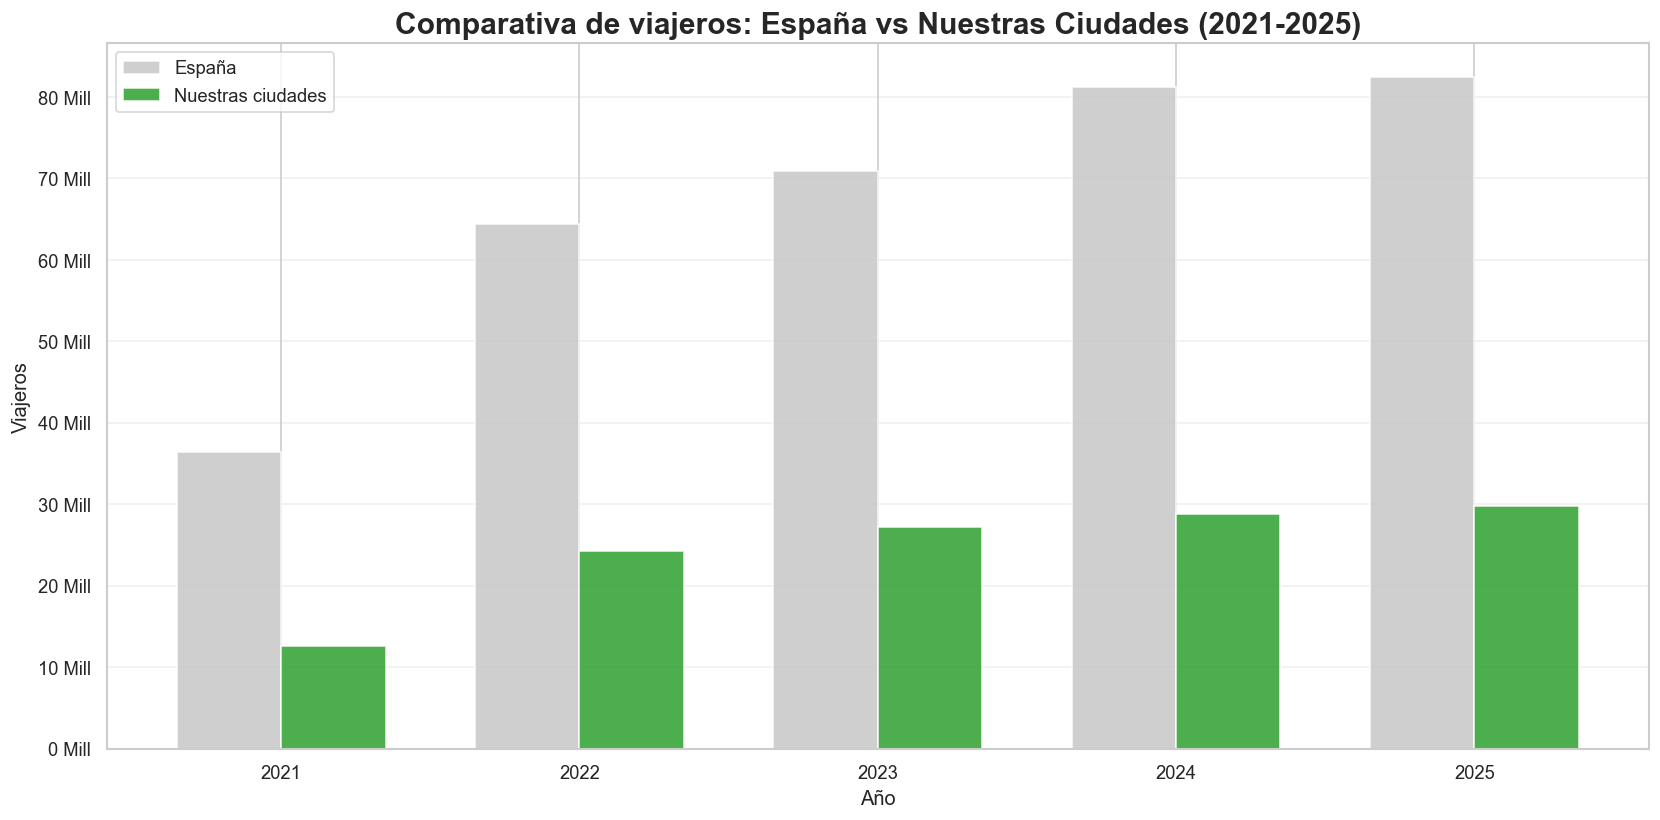

In [13]:

# --- Formateador para mostrar valores en millones ---
def millones(x, pos):
    return f"{x/1_000_000:.0f} Mill"


# --- Totales por año en España ---
tabla['Total'] = tabla['Españoles'] + tabla['Extranjeros']

# --- Totales por año en tus ciudades ---
tabla_ciudades['Total'] = tabla_ciudades['Españoles'] + tabla_ciudades['Extranjeros']


# --- Crear figura ---
plt.figure(figsize=(14,7))

# Barras agrupadas
ancho = 0.35
x = tabla['año']

plt.bar(x - ancho/2, tabla['Total'], width=ancho, label='España', color='#c7c7c7', alpha=0.85)
plt.bar(x + ancho/2, tabla_ciudades['Total'], width=ancho, label='Nuestras ciudades', color='#2ca02c', alpha=0.85)

# Título
plt.title("Comparativa de viajeros: España vs Nuestras Ciudades (2021-2025)", fontsize=18, fontweight='bold')

# Ejes
plt.xlabel("Año")
plt.ylabel("Viajeros")
plt.xticks(x.astype(int))

# Formato en millones
plt.gca().yaxis.set_major_formatter(FuncFormatter(millones))

# Cuadrícula
plt.grid(axis='y', alpha=0.3)

# Leyenda
plt.legend()

plt.tight_layout()
plt.show()


**Interpretación técnica:** El gráfico compara el volumen total de viajeros en España con el volumen que llega específicamente a nuestras ciudades entre 2021 y 2025. En todos los años, el total nacional es superior, pero ambas curvas muestran una tendencia claramente creciente.
La distancia entre ambas series se mantiene relativamente estable en términos absolutos, pero en términos relativos se observa que la proporción de viajeros que eligen nuestras ciudades aumenta ligeramente con el tiempo. Esto se debe a que el crecimiento en nuestras ciudades es más acelerado que el crecimiento total del país, especialmente a partir de 2022.
La serie nacional pasa de aproximadamente 36 millones a más de 82 millones, mientras que nuestras ciudades pasan de 12,5 millones a casi 30 millones. Aunque el volumen absoluto es menor, la pendiente de crecimiento es más pronunciada en nuestras ciudades, lo que indica una mayor capacidad de atracción relativa dentro del conjunto del turismo español.

**Interpretación de negocio:** El gráfico confirma que nuestras ciudades están ganando peso dentro del mercado turístico español. Aunque España en su conjunto crece, nuestras ciudades crecen más rápido, lo que implica una mejora en su posicionamiento y competitividad.
Para StaySpain, esto significa que la estrategia actual está funcionando: los destinos donde operamos están captando una proporción creciente del turismo total del país. Esto abre oportunidades para reforzar la presencia en estos destinos, ampliar oferta y optimizar precios, especialmente en temporadas de alta demanda.
El hecho de que la brecha entre España y nuestras ciudades se mantenga estable en volumen pero se reduzca en términos relativos indica que nuestras ciudades están consolidándose como polos turísticos de referencia. Esto permite a StaySpain plantear estrategias de expansión, alianzas locales y campañas específicas que aprovechen esta tendencia positiva


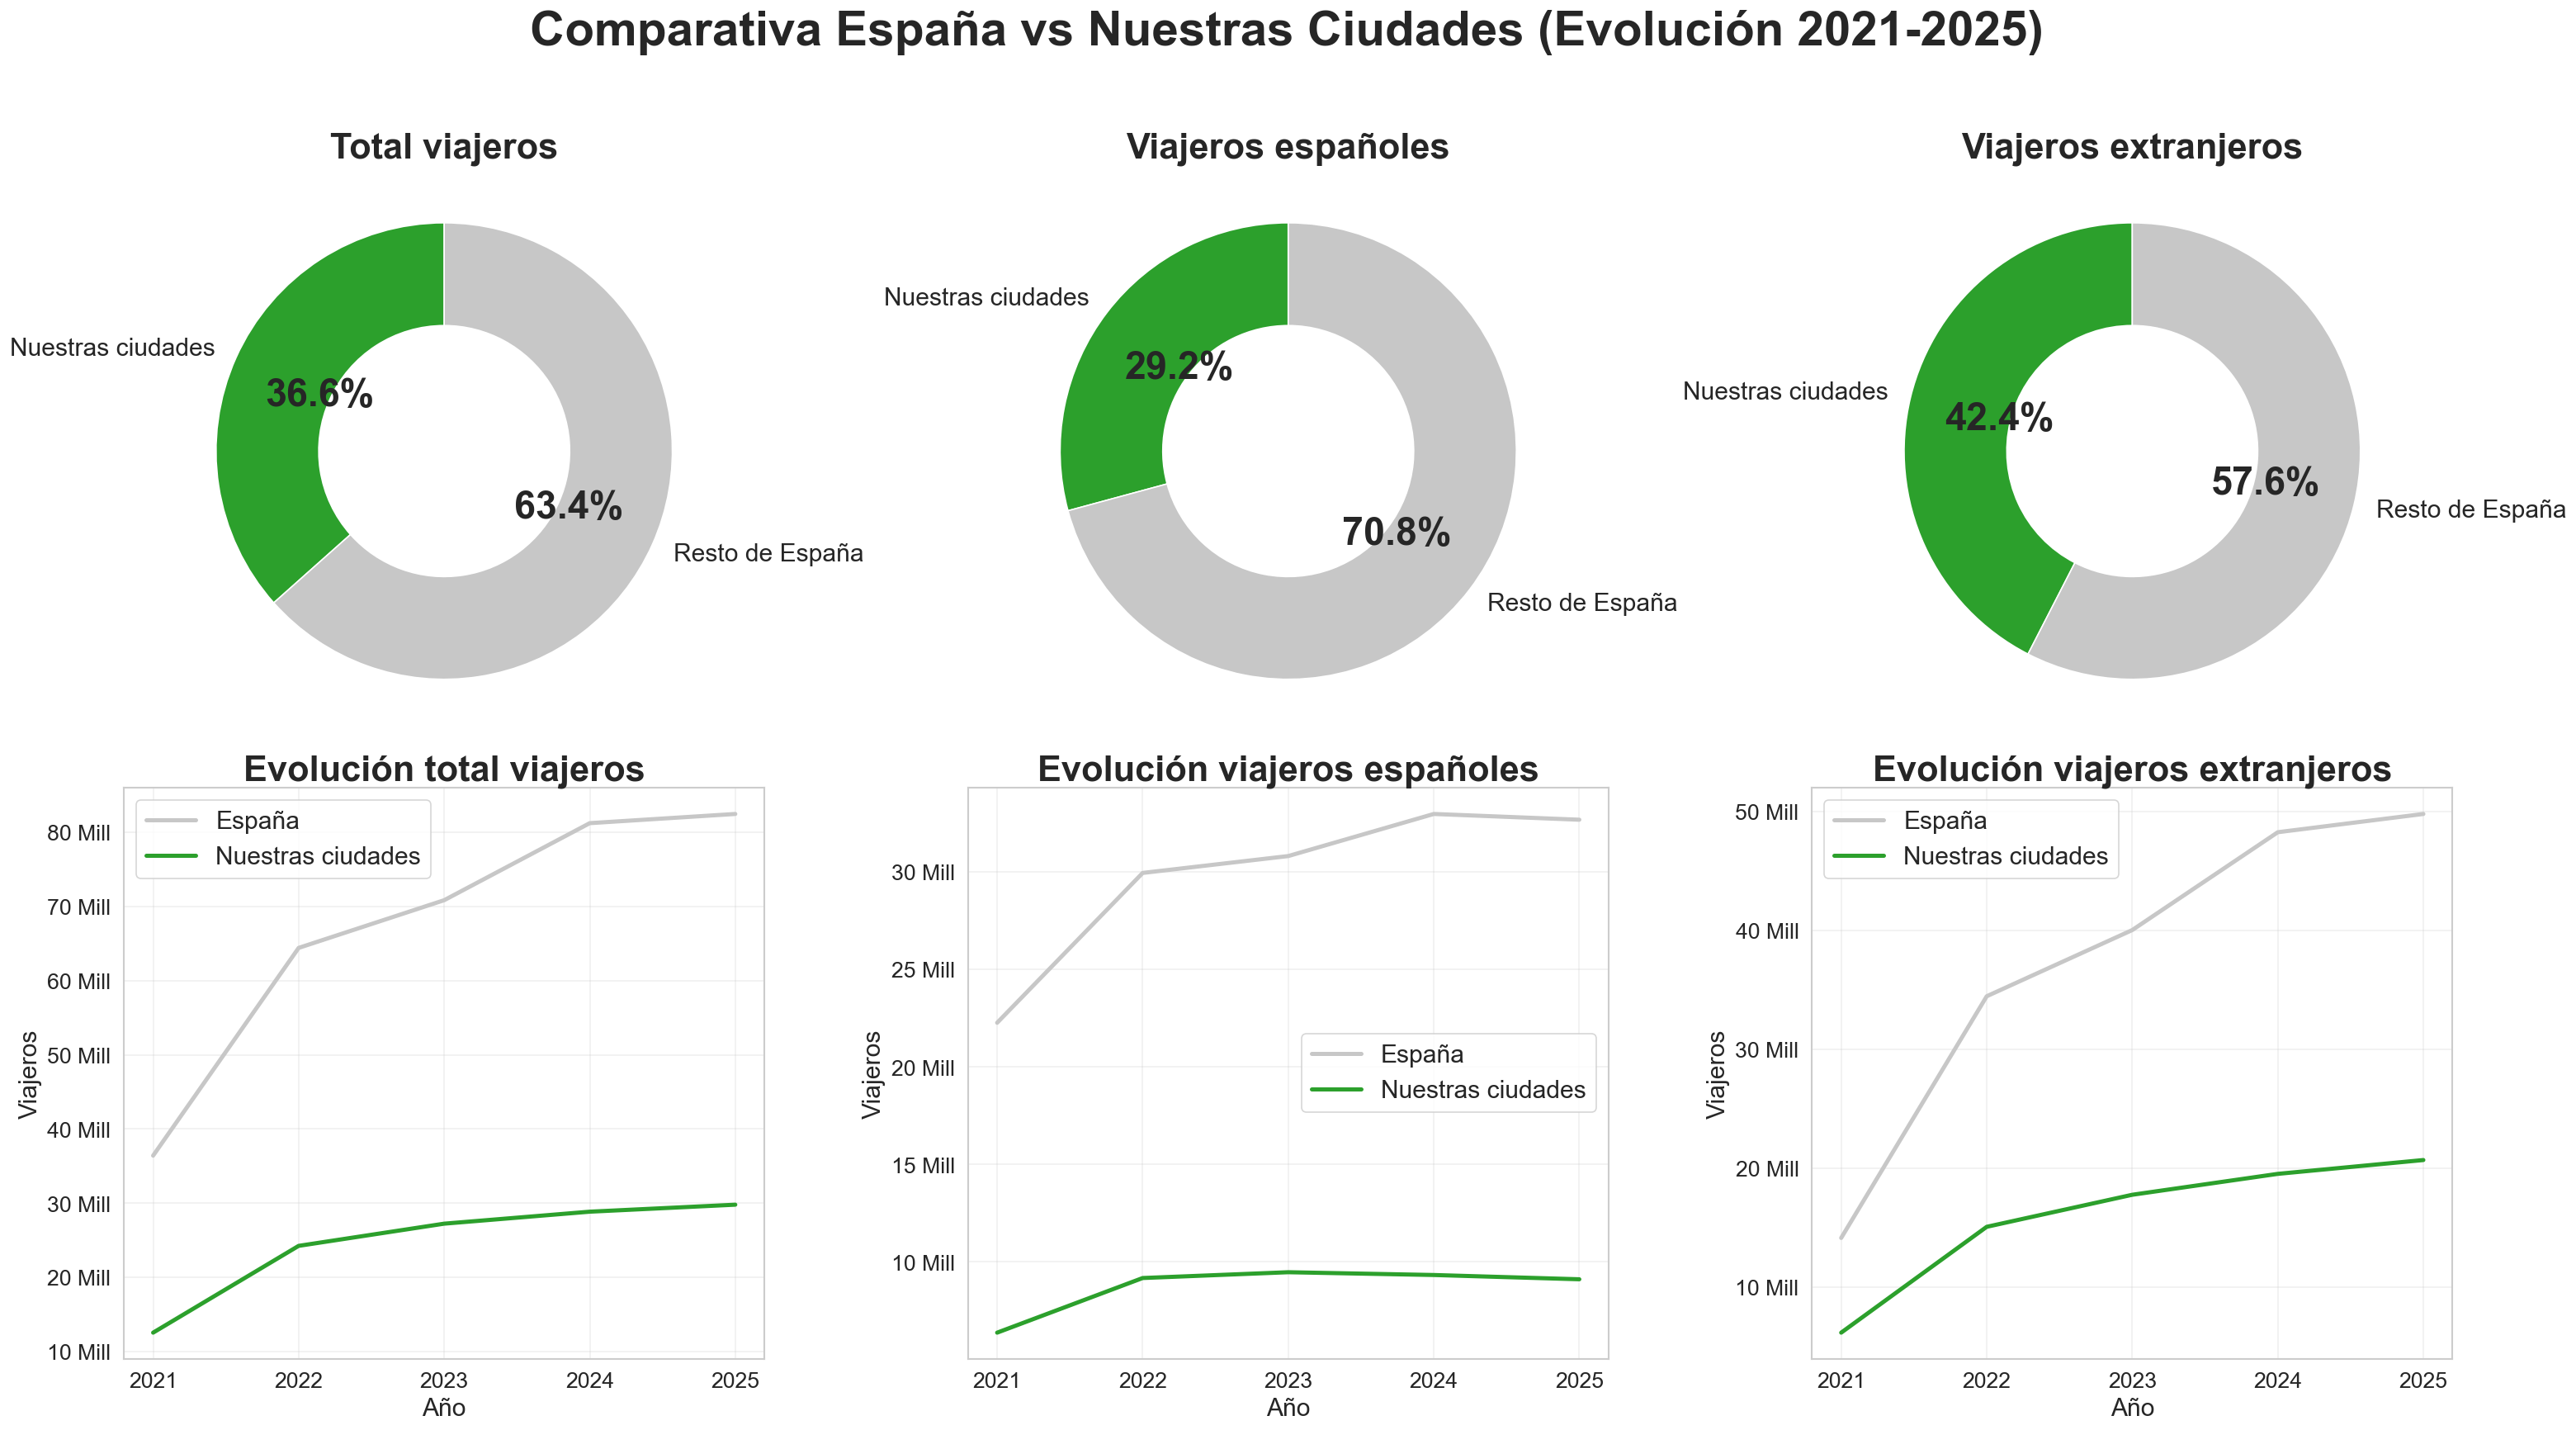

In [72]:

# ============================
# 1) CÁLCULOS GENERALES
# ============================

# Totales España
total_españa_es = tabla['Españoles'].sum()
total_españa_ex = tabla['Extranjeros'].sum()
total_españa = total_españa_es + total_españa_ex

# Totales Nuestras ciudades
total_ciudades_es = tabla_ciudades['Españoles'].sum()
total_ciudades_ex = tabla_ciudades['Extranjeros'].sum()
total_ciudades = total_ciudades_es + total_ciudades_ex

# Porcentajes
porc_total_ciudades = total_ciudades / total_españa * 100
porc_total_resto = 100 - porc_total_ciudades

porc_es_ciudades = total_ciudades_es / total_españa_es * 100
porc_es_resto = 100 - porc_es_ciudades

porc_ex_ciudades = total_ciudades_ex / total_españa_ex * 100
porc_ex_resto = 100 - porc_ex_ciudades


# ============================
# 2) FIGURA CON 2 FILAS (3 + 3)
# ============================

fig, axes = plt.subplots(2, 3, figsize=(26,14))

# Paleta
col_ciudades = '#2ca02c'   # verde
col_resto = '#c7c7c7'      # gris claro

# Tamaños de texto
size_title_general = 35
size_title = 26
size_label = 18
size_pct = 28
size_ticks = 16


# ============================
# FILA 1 — DONUTS
# ============================

# ----------------------------
# DONUT 1 — TOTAL
# ----------------------------
wedges, texts, autotexts = axes[0,0].pie(
    [porc_total_ciudades, porc_total_resto],
    labels=['Nuestras ciudades', 'Resto de España'],
    autopct='%1.1f%%',
    colors=[col_ciudades, col_resto],
    startangle=90,
    wedgeprops={'width': 0.45}
)

for t in autotexts:
    t.set_fontsize(size_pct)
    t.set_weight('bold')

for t in texts:
    t.set_fontsize(size_label)

axes[0,0].set_title("Total viajeros", fontsize=size_title, fontweight='bold')


# ----------------------------
# DONUT 2 — ESPAÑOLES
# ----------------------------
wedges, texts, autotexts = axes[0,1].pie(
    [porc_es_ciudades, porc_es_resto],
    labels=['Nuestras ciudades', 'Resto de España'],
    autopct='%1.1f%%',
    colors=[col_ciudades, col_resto],
    startangle=90,
    wedgeprops={'width': 0.45}
)

for t in autotexts:
    t.set_fontsize(size_pct)
    t.set_weight('bold')

for t in texts:
    t.set_fontsize(size_label)

axes[0,1].set_title("Viajeros españoles", fontsize=size_title, fontweight='bold')


# ----------------------------
# DONUT 3 — EXTRANJEROS
# ----------------------------
wedges, texts, autotexts = axes[0,2].pie(
    [porc_ex_ciudades, porc_ex_resto],
    labels=['Nuestras ciudades', 'Resto de España'],
    autopct='%1.1f%%',
    colors=[col_ciudades, col_resto],
    startangle=90,
    wedgeprops={'width': 0.45}
)

for t in autotexts:
    t.set_fontsize(size_pct)
    t.set_weight('bold')

for t in texts:
    t.set_fontsize(size_label)

axes[0,2].set_title("Viajeros extranjeros", fontsize=size_title, fontweight='bold')


# ============================
# FILA 2 — EVOLUCIÓN 5 AÑOS
# ============================

# Formateador en millones
def millones(x, pos):
    return f"{x/1_000_000:.0f} Mill"


# ----------------------------
# EVOLUCIÓN TOTAL
# ----------------------------
axes[1,0].plot(tabla['año'], tabla['Españoles'] + tabla['Extranjeros'],
               label='España', color=col_resto, linewidth=3)

axes[1,0].plot(tabla_ciudades['año'], tabla_ciudades['Españoles'] + tabla_ciudades['Extranjeros'],
               label='Nuestras ciudades', color=col_ciudades, linewidth=3)

axes[1,0].set_title("Evolución total viajeros", fontsize=size_title, fontweight='bold')
axes[1,0].set_xlabel("Año", fontsize=size_label)
axes[1,0].set_ylabel("Viajeros", fontsize=size_label)
axes[1,0].legend(fontsize=size_label)
axes[1,0].grid(alpha=0.3)
axes[1,0].yaxis.set_major_formatter(FuncFormatter(millones))

axes[1,0].set_xticks(tabla['año'])
axes[1,0].set_xticklabels(tabla['año'].astype(int), fontsize=size_ticks)
axes[1,0].tick_params(axis='y', labelsize=size_ticks)


# ----------------------------
# EVOLUCIÓN ESPAÑOLES
# ----------------------------
axes[1,1].plot(tabla['año'], tabla['Españoles'],
               label='España', color=col_resto, linewidth=3)

axes[1,1].plot(tabla_ciudades['año'], tabla_ciudades['Españoles'],
               label='Nuestras ciudades', color=col_ciudades, linewidth=3)

axes[1,1].set_title("Evolución viajeros españoles", fontsize=size_title, fontweight='bold')
axes[1,1].set_xlabel("Año", fontsize=size_label)
axes[1,1].set_ylabel("Viajeros", fontsize=size_label)
axes[1,1].legend(fontsize=size_label)
axes[1,1].grid(alpha=0.3)
axes[1,1].yaxis.set_major_formatter(FuncFormatter(millones))

axes[1,1].set_xticks(tabla['año'])
axes[1,1].set_xticklabels(tabla['año'].astype(int), fontsize=size_ticks)
axes[1,1].tick_params(axis='y', labelsize=size_ticks)


# ----------------------------
# EVOLUCIÓN EXTRANJEROS
# ----------------------------
axes[1,2].plot(tabla['año'], tabla['Extranjeros'],
               label='España', color=col_resto, linewidth=3)

axes[1,2].plot(tabla_ciudades['año'], tabla_ciudades['Extranjeros'],
               label='Nuestras ciudades', color=col_ciudades, linewidth=3)

axes[1,2].set_title("Evolución viajeros extranjeros", fontsize=size_title, fontweight='bold')
axes[1,2].set_xlabel("Año", fontsize=size_label)
axes[1,2].set_ylabel("Viajeros", fontsize=size_label)
axes[1,2].legend(fontsize=size_label)
axes[1,2].grid(alpha=0.3)
axes[1,2].yaxis.set_major_formatter(FuncFormatter(millones))

axes[1,2].set_xticks(tabla['año'])
axes[1,2].set_xticklabels(tabla['año'].astype(int), fontsize=size_ticks)
axes[1,2].tick_params(axis='y', labelsize=size_ticks)


# ============================
# TÍTULO GENERAL
# ============================
fig.suptitle(
    "Comparativa España vs Nuestras Ciudades (Evolución 2021-2025)",
    fontsize=size_title_general,
    fontweight='bold',
    y=1.03
)

plt.tight_layout()
plt.show()


**Interpretación técnica:** Las visualizaciones comparan la cuota de viajeros que captan nuestras ciudades frente al total de España entre 2021 y 2025. Los gráficos circulares muestran que nuestras ciudades concentran el 36,6% del total de viajeros, pero con una diferencia clara por segmento: solo captan el 29,2% de los españoles, mientras que alcanzan un 42,4% de los extranjeros. Esto indica una mayor afinidad del turismo internacional hacia estos destinos.
Las series temporales refuerzan esta lectura: tanto España como nuestras ciudades crecen de forma sostenida, pero la pendiente de crecimiento es más pronunciada en nuestras ciudades, especialmente en el segmento extranjero. La evolución anual muestra que la brecha relativa se reduce ligeramente, lo que implica que nuestras ciudades están ganando peso dentro del conjunto del turismo nacional.
En el caso de los viajeros españoles, la proporción que elige nuestras ciudades se mantiene estable, mientras que en el caso de los extranjeros se observa un crecimiento más acelerado, lo que explica la mayor cuota internacional observada en el agregado.

**Interpretación de negocio:** Las ciudades donde opera StaySpain tienen un posicionamiento especialmente fuerte en el mercado internacional: captan a más de cuatro de cada diez turistas extranjeros que llegan a España. Esto convierte al turismo internacional en el principal motor de crecimiento y en la mayor oportunidad estratégica para la compañía.
El mercado nacional, aunque relevante, muestra una penetración más limitada (29,2%), lo que sugiere que existe margen para mejorar la captación doméstica mediante campañas específicas, ofertas de escapadas y estrategias de proximidad.
El crecimiento más rápido de nuestras ciudades frente al total de España indica que estos destinos están ganando atractivo y cuota de mercado. Para StaySpain, esto implica que reforzar la presencia en estos destinos —especialmente en mercados emisores internacionales— puede generar un impacto directo en volumen, ingresos y visibilidad de marca.
La estrategia óptima es dual: potenciar la captación internacional en primavera y verano, donde la demanda es más fuerte y menos sensible al precio, y activar el mercado nacional en otoño e invierno para estabilizar la ocupación y mantener ingresos constantes.


## Media por mes

In [15]:
df_viajeros_total = df_ciudades[df_ciudades['Viajeros y pernoctaciones'] == 'Viajero']

df_viajeros_mis_ciudades = df_viajeros_total[
    df_viajeros_total['nombre_ciudad'].isin(MIS_CIUDADES)
]


In [16]:
# SUMA mensual por año (España)
suma_mensual_españa = (
    df_viajeros_total[df_viajeros_total['Total'].notna()]
    .groupby(['año', 'mes'])['Total']
    .sum()
)


# MEDIA mensual (España)
media_mensual_españa = (
    suma_mensual_españa
    .groupby('mes')
    .sum() / 5
)

media_mensual_españa = media_mensual_españa.round(0).astype(int)

print("\n=== Media mensual viajeros que recibimos en toda España ===")
display(media_mensual_españa)



=== Media mensual viajeros que recibimos en toda España ===


mes
1     3118898
2     3584575
3     4402504
4     5371098
5     6179243
6     6628689
7     7373383
8     7813544
9     6954711
10    6625859
11    4642892
12    4367451
Name: Total, dtype: int32

In [17]:
# SUMA mensual por año (Nuestras ciudades)
suma_mensual_mis_ciudades = (
    df_viajeros_mis_ciudades[df_viajeros_mis_ciudades['Total'].notna()]
    .groupby(['año', 'mes'])['Total']
    .sum()
)

# MEDIA mensual (Nuestras ciudades)
media_mensual_mis_ciudades = (
    suma_mensual_mis_ciudades
    .groupby('mes')
    .sum() / 5
)

media_mensual_mis_ciudades = media_mensual_mis_ciudades.round(0).astype(int)

print("\n=== Media mensual viajeros que recibimos en nuestras ciudades ===")
display(media_mensual_mis_ciudades)



=== Media mensual viajeros que recibimos en nuestras ciudades ===


mes
1     1356004
2     1501580
3     1798092
4     2003133
5     2242649
6     2274916
7     2370511
8     2305227
9     2350428
10    2447939
11    2001762
12    1877594
Name: Total, dtype: int32

In [18]:
# Filtrar solo españoles en toda España
df_españa_es = df_viajeros_total[
    (df_viajeros_total['Residencia'] == 'Residentes en España') &
    (df_viajeros_total['Total'].notna())
]

# Suma por año y mes
mensual_españa_es = (
    df_españa_es.groupby(['año', 'mes'])['Total']
    .sum()
    .reset_index()
)

# Media mensual (5 años)
media_mensual_españa_es = (
    mensual_españa_es.groupby('mes')['Total'].sum() / 5
).round(0).astype(int)


In [19]:
# Filtrar solo españoles en nuestras ciudades
df_ciudades_es = df_viajeros_mis_ciudades[
    (df_viajeros_mis_ciudades['Residencia'] == 'Residentes en España') &
    (df_viajeros_mis_ciudades['Total'].notna())
]

mensual_mis_ciudades_es = (
    df_ciudades_es.groupby(['año', 'mes'])['Total']
    .sum()
    .reset_index()
)

media_mensual_mis_ciudades_es = (
    mensual_mis_ciudades_es.groupby('mes')['Total'].sum() / 5
).round(0).astype(int)


In [20]:
# # Filtrar solo extranjeros en toda Esapña
df_españa_ex = df_viajeros_total[
    (df_viajeros_total['Residencia'] == 'Residentes en el Extranjero') &
    (df_viajeros_total['Total'].notna())
]

mensual_españa_ex = (
    df_españa_ex.groupby(['año', 'mes'])['Total']
    .sum()
    .reset_index()
)

media_mensual_españa_ex = (
    mensual_españa_ex.groupby('mes')['Total'].sum() / 5
).round(0).astype(int)


In [21]:
# Filtrar solo extranjeros en nuestras ciudades
df_ciudades_ex = df_viajeros_mis_ciudades[
    (df_viajeros_mis_ciudades['Residencia'] == 'Residentes en el Extranjero') &
    (df_viajeros_mis_ciudades['Total'].notna())
]

mensual_mis_ciudades_ex = (
    df_ciudades_ex.groupby(['año', 'mes'])['Total']
    .sum()
    .reset_index()
)

media_mensual_mis_ciudades_ex = (
    mensual_mis_ciudades_ex.groupby('mes')['Total'].sum() / 5
).round(0).astype(int)


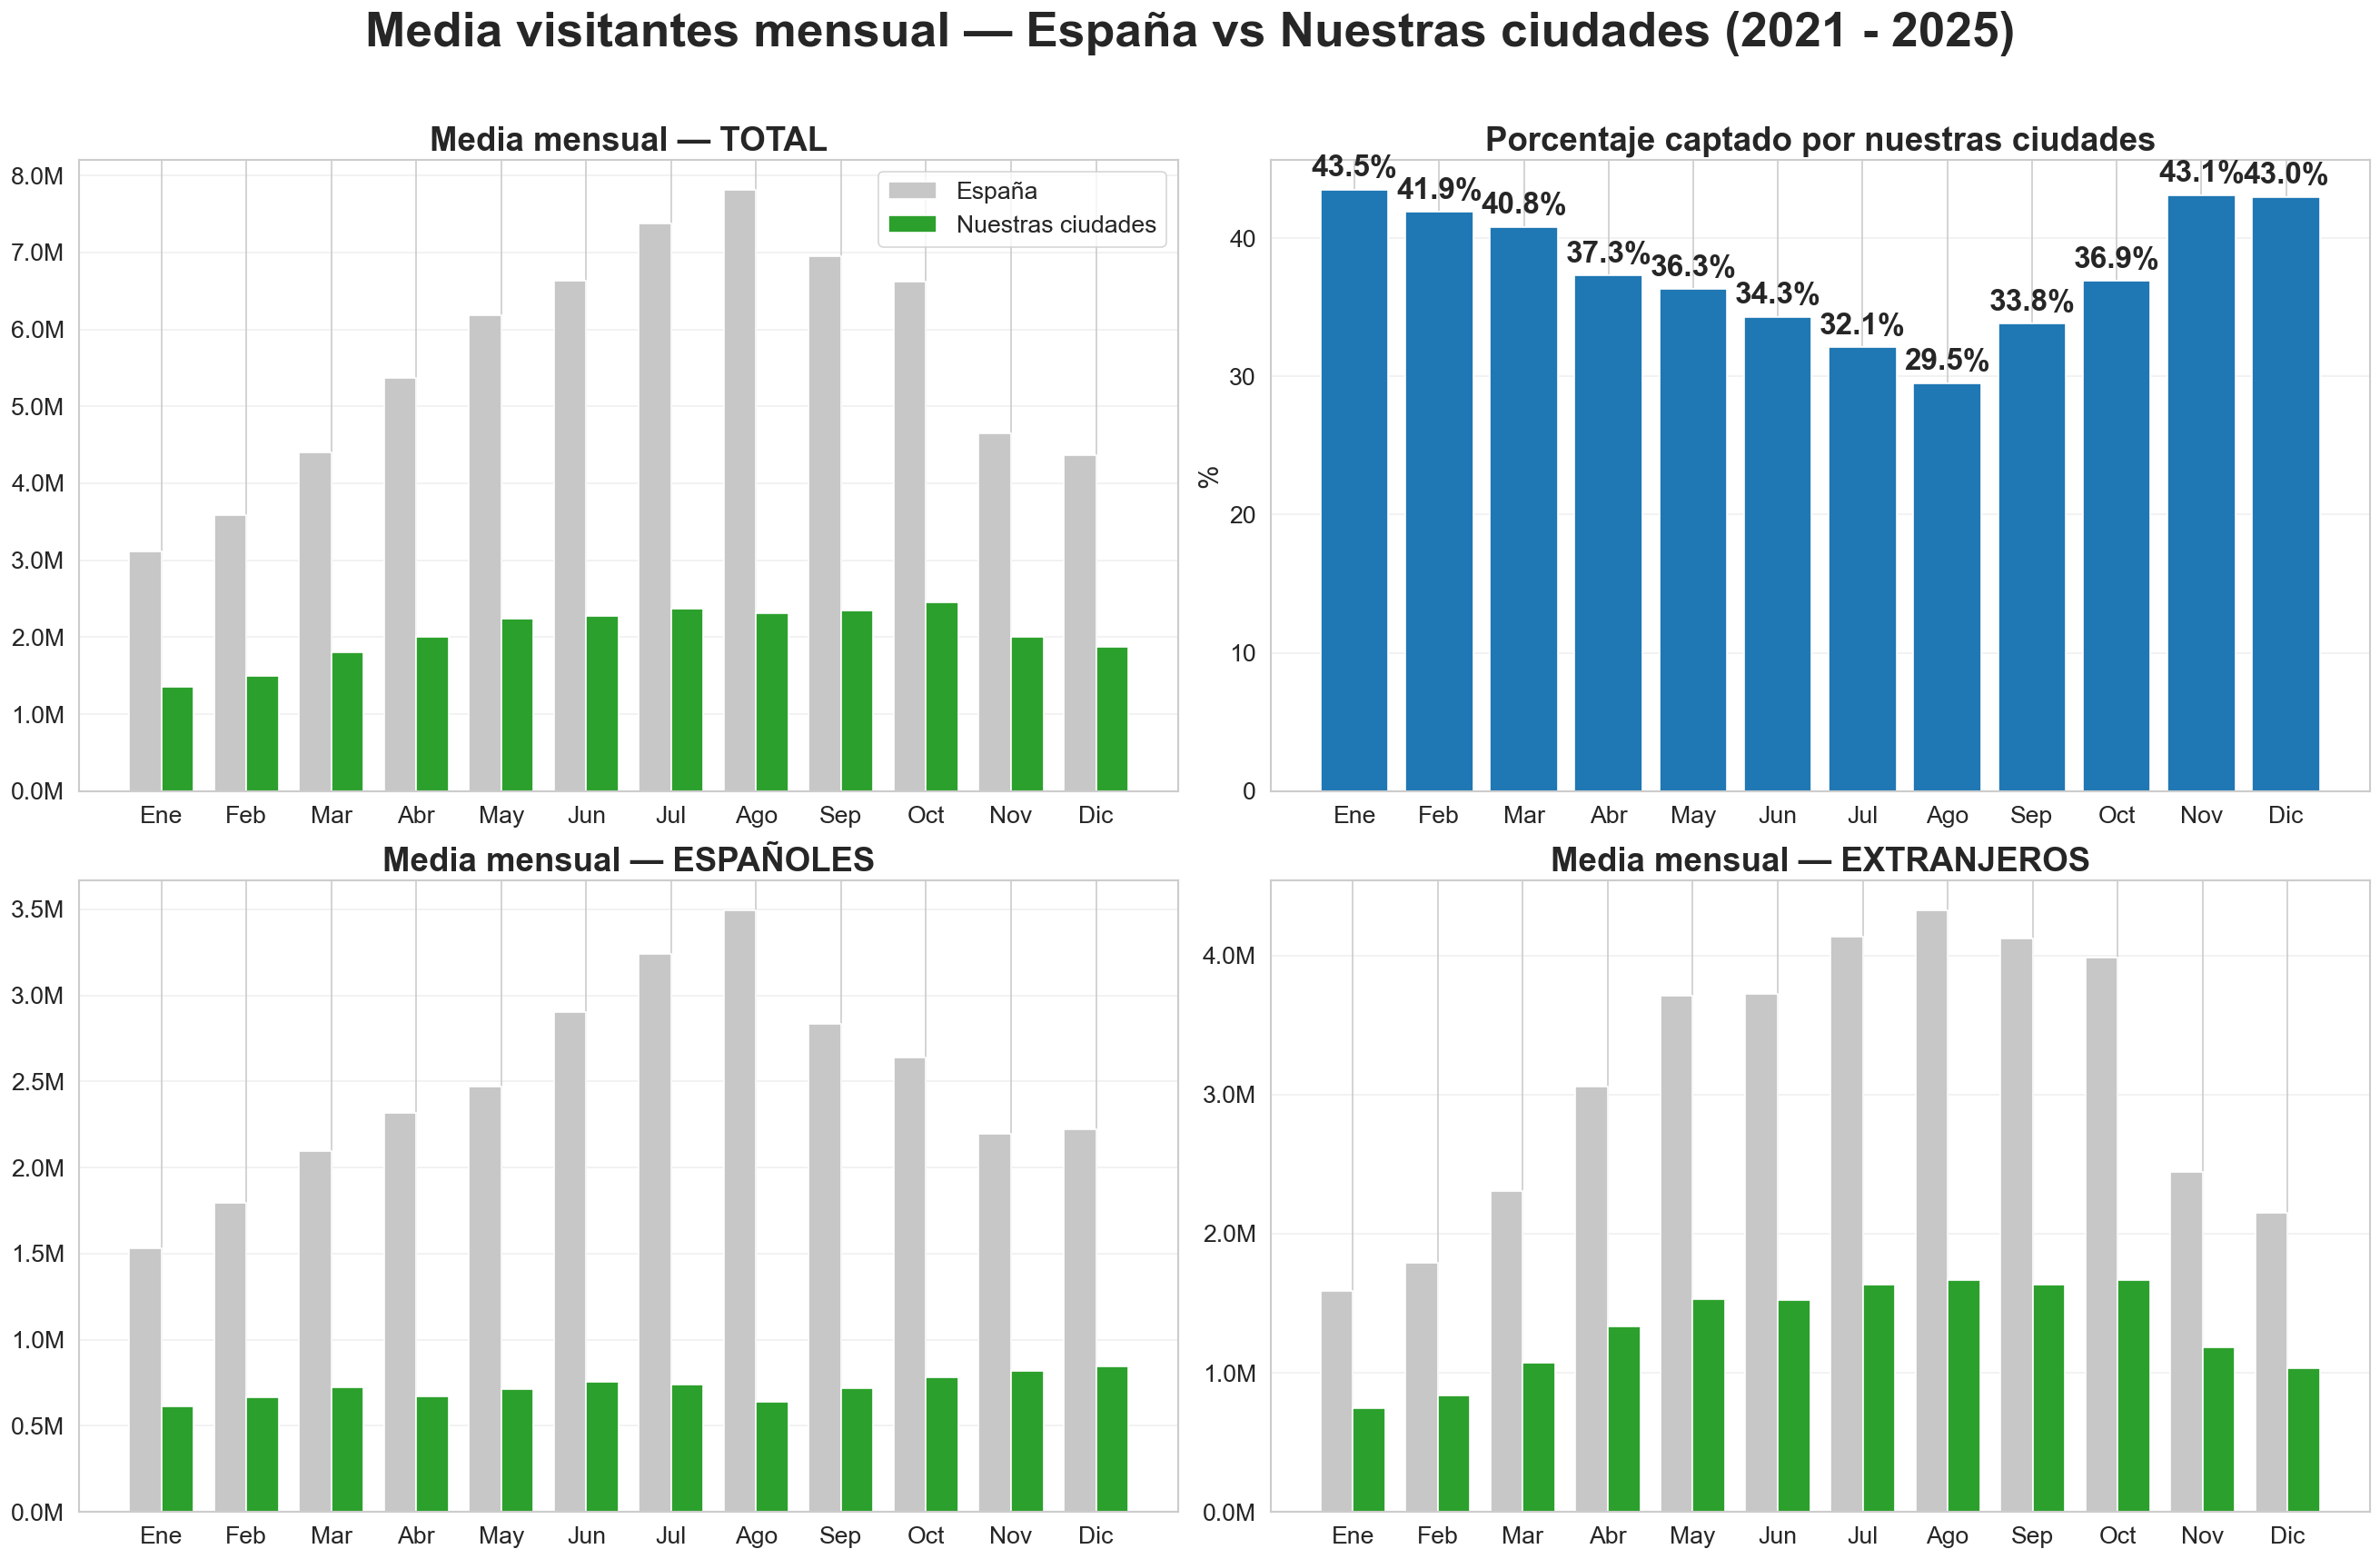

In [22]:

# Formateador en millones
def millones(x, pos):
    return f"{x/1_000_000:.1f}M"

# ============================
# PREPARAR DATOS
# ============================

meses = media_mensual_españa.index
meses_nombres = [MESES_ES[m] for m in meses]

# Total
es_total = media_mensual_españa.values
ci_total = media_mensual_mis_ciudades.values

# Españoles
es_espa = media_mensual_españa_es.values
ci_espa = media_mensual_mis_ciudades_es.values

# Extranjeros
es_ext = media_mensual_españa_ex.values
ci_ext = media_mensual_mis_ciudades_ex.values

# Porcentaje captado por tus ciudades
pct_ciudades = (ci_total / es_total * 100).round(1)

# ============================
# FIGURA 2×2
# ============================

fig, axes = plt.subplots(2, 2, figsize=(22,14))
x = np.arange(len(meses))
width = 0.38

# ============================
# 1) TOTAL
# ============================
ax = axes[0,0]
ax.bar(x - width/2, es_total, width, color='#c7c7c7', label='España')
ax.bar(x + width/2, ci_total, width, color='#2ca02c', label='Nuestras ciudades')

ax.set_title("Media mensual — TOTAL", fontsize=22, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(meses_nombres, fontsize=16)
ax.tick_params(axis='y', labelsize=16)
ax.grid(axis='y', alpha=0.3)
ax.yaxis.set_major_formatter(FuncFormatter(millones))
ax.legend(fontsize=16)

# ============================
# 2) PORCENTAJE CAPTADO
# ============================
ax = axes[0,1]
bars = ax.bar(x, pct_ciudades, color='#1f77b4')
ax.bar(x, pct_ciudades, color='#1f77b4')

ax.set_title("Porcentaje captado por nuestras ciudades", fontsize=22, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(meses_nombres, fontsize=16)
ax.tick_params(axis='y', labelsize=16)
ax.grid(axis='y', alpha=0.3)
ax.set_ylabel("%", fontsize=18)

# Añadir etiquetas encima de cada barra
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f"{pct_ciudades[i]}%",
        ha='center', va='bottom',
        fontsize=20, fontweight='bold'
    )

# ============================
# 3) ESPAÑOLES
# ============================
ax = axes[1,0]
ax.bar(x - width/2, es_espa, width, color='#c7c7c7')
ax.bar(x + width/2, ci_espa, width, color='#2ca02c')

ax.set_title("Media mensual — ESPAÑOLES", fontsize=22, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(meses_nombres, fontsize=16)
ax.tick_params(axis='y', labelsize=16)
ax.grid(axis='y', alpha=0.3)
ax.yaxis.set_major_formatter(FuncFormatter(millones))

# ============================
# 4) EXTRANJEROS
# ============================
ax = axes[1,1]
ax.bar(x - width/2, es_ext, width, color='#c7c7c7')
ax.bar(x + width/2, ci_ext, width, color='#2ca02c')

ax.set_title("Media mensual — EXTRANJEROS", fontsize=22, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(meses_nombres, fontsize=16)
ax.tick_params(axis='y', labelsize=16)
ax.grid(axis='y', alpha=0.3)
ax.yaxis.set_major_formatter(FuncFormatter(millones))

# ============================
# TÍTULO GENERAL
# ============================
fig.suptitle("Media visitantes mensual — España vs Nuestras ciudades (2021 - 2025)",
             fontsize=32, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()


**Interpretación técnica:** Las gráficas comparan la media mensual de viajeros en España frente a nuestras ciudades y muestran cómo varía la cuota captada por estas a lo largo del año. En términos absolutos, España presenta una fuerte estacionalidad, con picos muy marcados en julio y agosto tanto en el total como en los segmentos de españoles y extranjeros. En contraste, nuestras ciudades muestran un patrón más estable, con variaciones menos pronunciadas entre meses.
El porcentaje captado por nuestras ciudades oscila entre el 29,5% en agosto y el 43–44% en los meses de invierno, lo que indica que la cuota relativa es mayor cuando la demanda nacional e internacional es más baja. La caída progresiva desde enero hasta agosto refleja que, en temporada alta, el crecimiento del turismo en España se concentra más en destinos de playa y vacacionales, mientras que nuestras ciudades mantienen un flujo más constante.
En los segmentos por residencia, se observa que la captación de españoles es más baja en verano, mientras que la de extranjeros se mantiene más estable, aunque también disminuye en los meses de mayor volumen nacional. Esto confirma que la estacionalidad afecta de forma diferente a cada segmento.

**Interpretación de negocio:** Las ciudades donde opera StaySpain funcionan como destinos menos estacionales que el conjunto de España, lo que es una ventaja competitiva clara: mantienen una cuota elevada en meses valle (enero, noviembre, diciembre) y sufren menos volatilidad. Esto permite estabilizar ingresos y ocupación durante todo el año.
La caída de cuota en verano indica que, durante la temporada alta, los viajeros —especialmente los nacionales— se desplazan hacia destinos de sol y playa, reduciendo el peso relativo de nuestras ciudades. Para StaySpain, esto implica que la estrategia debe diferenciarse por temporada:

 - Invierno y meses valle: reforzar campañas urbanas, escapadas culturales y city breaks, donde nuestras ciudades captan más del 40% del mercado.

 - Verano: potenciar la captación internacional, especialmente de mercados europeos que mantienen un interés más estable por destinos urbanos, y ajustar precios para maximizar ingresos en un contexto de menor cuota relativa.
El comportamiento más estable del turismo extranjero sugiere que este segmento es clave para sostener la ocupación anual. La menor estacionalidad de nuestras ciudades convierte a StaySpain en una plataforma con capacidad para suavizar los ciclos del mercado turístico español y aprovechar oportunidades tanto en temporada alta como en baja.


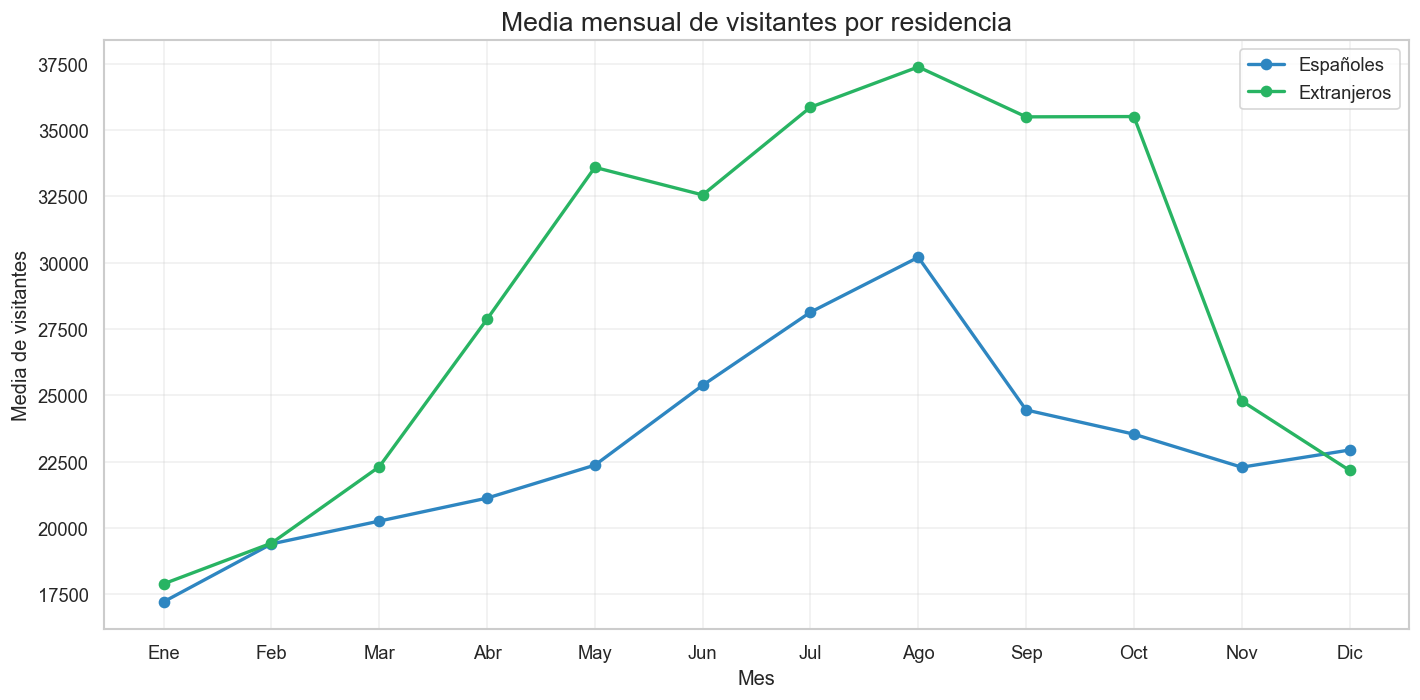

In [84]:
# Comparación de estacionalidad por mes entre viajeros de origen nacional e internacional

# --- 1. Filtrar solo viajeros ---
df = df_ciudades[df_ciudades['Viajeros y pernoctaciones'] == 'Viajero'].copy()

# --- 2. Mapear mes numérico a nombre ---
mapa_meses = {
    1: "Ene", 2: "Feb", 3: "Mar", 4: "Abr", 5: "May", 6: "Jun",
    7: "Jul", 8: "Ago", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dic"
}
df['mes_nombre'] = df['mes'].map(mapa_meses)

# --- 3. Orden correcto de meses ---
orden_meses = ["Ene", "Feb", "Mar", "Abr", "May", "Jun",
               "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]
df['mes_nombre'] = pd.Categorical(df['mes_nombre'], categories=orden_meses, ordered=True)

# --- 4. Agrupar por residencia y mes ---
media_mensual = (
    df.groupby(['Residencia', 'mes_nombre'])['Total']
      .mean()
      .reset_index()
)

# --- 5. Pivot para alinear series ---
pivot = media_mensual.pivot(index='mes_nombre', columns='Residencia', values='Total')

# --- 6. Gráfica ---
plt.figure(figsize=(12, 6))

plt.plot(pivot.index, pivot['Residentes en España'], marker='o', linewidth=2,
         color='#2E86C1', label='Españoles')

plt.plot(pivot.index, pivot['Residentes en el Extranjero'], marker='o', linewidth=2,
         color='#28B463', label='Extranjeros')

plt.title('Media mensual de visitantes por residencia', fontsize=16)
plt.xlabel('Mes')
plt.ylabel('Media de visitantes')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


**Interpretación técnica:** La gráfica muestra la media mensual de visitantes diferenciando entre Residentes en España y Residentes en el Extranjero. Ambas series presentan un patrón estacional muy marcado: valores bajos en invierno, crecimiento progresivo hacia primavera y un pico claro en los meses de verano.
Los visitantes extranjeros muestran un incremento más pronunciado, alcanzando su máximo en agosto, mientras que los españoles tienden a concentrarse ligeramente antes, con un pico entre junio y julio.
Tras el verano, ambas curvas descienden de forma sostenida hasta diciembre, reflejando la estacionalidad típica del turismo en España. La serie extranjera mantiene valores superiores a la española durante todo el año, lo que indica una mayor contribución media mensual del turismo internacional.

**Interpretación de negocio:** El comportamiento confirma que el turismo en España es altamente estacional, con una fuerte concentración en los meses de verano. Para StaySpain, esto implica que la demanda internacional es el principal motor del pico estival, especialmente en agosto, mientras que el turismo nacional aporta volumen relevante pero con un adelanto temporal del consumo.
La diferencia entre ambas curvas sugiere que las estrategias comerciales deben adaptarse:
 - Internacional: campañas orientadas a verano, paquetes de larga estancia y refuerzo de destinos de sol y playa.
 - Nacional: promoción de escapadas en primavera y principios de verano, aprovechando su pico adelantado.
El descenso progresivo hacia final de año abre oportunidades para estrategias antiestacionalidad, como city breaks, eventos culturales y promociones específicas para mercados con menor sensibilidad climática


# 3.- Destino del viajero Español

In [73]:
# TOP 10 de la Suma de viajeros españoles por ciudad destino de toda España
suma_españoles_por_ciudad = (
    df_viajeros_total[
        df_viajeros_total['Residencia'] == 'Residentes en España'
    ]
    .groupby('nombre_ciudad')['Total']
    .sum()
    .sort_values(ascending=False)
)

# Calcular el total nacional de españoles
total_españa_es = suma_españoles_por_ciudad.sum()

# Crear DataFrame con porcentaje
df_españoles_por_ciudad = suma_españoles_por_ciudad.to_frame(name='Total Españoles')
df_españoles_por_ciudad['% del total'] = (
    df_españoles_por_ciudad['Total Españoles'] / total_españa_es * 100
).round(2)

# Añadir columna de ranking
df_españoles_por_ciudad['Ranking Nacional'] = range(1, len(df_españoles_por_ciudad) + 1)

# Mostrar TOP 10
print("=== TOP TEN DESTINOS DEL VIEJERO ESPAÑOL ===")
display(df_españoles_por_ciudad.head(10))


=== TOP TEN DESTINOS DEL VIEJERO ESPAÑOL ===


,Total Españoles,% del total,Ranking Nacional
nombre_ciudad,,,
Madrid,20690590.0,13.92,1
Barcelona,7197727.0,4.84,2
Sevilla,6101580.0,4.10,3
Benidorm,4937749.0,3.32,4
València,4435580.0,2.98,5
Granada,4056698.0,2.73,6
Zaragoza,3835276.0,2.58,7
Málaga,2975317.0,2.00,8
Salou,2740453.0,1.84,9


**Interpretación técnica:** La tabla muestra el TOP 10 de destinos del viajero español según volumen total acumulado. Madrid destaca de forma abrumadora como primer destino nacional, concentrando el 13,92% de todos los viajes de españoles en España, más del doble que el segundo destino (Barcelona, 4,84%). A partir de la segunda posición, los porcentajes se distribuyen de forma más homogénea entre grandes ciudades y destinos turísticos consolidados como Sevilla, Benidorm, València o Granada.
La caída progresiva en el porcentaje —del 13,92% al 1,78%— indica una distribución larga y con fuerte concentración inicial: el primer destino acumula casi la misma cuota que los puestos 2 al 4 combinados. Esto evidencia un patrón de concentración típico de mercados urbanos y turísticos donde unos pocos destinos absorben la mayor parte del flujo nacional.
El ranking confirma que los destinos urbanos (Madrid, Barcelona, Sevilla, Zaragoza, Bilbao) conviven con destinos vacacionales (Benidorm, Salou) dentro del comportamiento del viajero español, mostrando una mezcla equilibrada entre turismo cultural/urbano y turismo de ocio.

**Interpretación de negocio:** El viajero español muestra una preferencia muy marcada por Madrid, lo que convierte a la capital en un destino estratégico para cualquier operador turístico que quiera maximizar captación nacional. Barcelona y Sevilla completan un triángulo de ciudades clave donde la presencia de StaySpain tiene un impacto directo en volumen y visibilidad.
La presencia de destinos vacacionales como Benidorm y Salou en el TOP 10 indica que el mercado nacional combina escapadas urbanas con turismo de sol y playa, lo que abre oportunidades para diversificar producto y campañas según temporada.
Para StaySpain, este ranking confirma que su portfolio está bien alineado con los destinos más demandados por los españoles (Madrid, Barcelona, Sevilla, Málaga, València), lo que facilita la captación nacional sin necesidad de grandes esfuerzos de reposicionamiento.
La fuerte concentración en los primeros puestos sugiere que reforzar presencia y acciones comerciales en Madrid y Barcelona puede generar retornos desproporcionadamente altos. Al mismo tiempo, destinos como Granada, Zaragoza o Bilbao representan oportunidades de crecimiento incremental donde la competencia es menor y la demanda sigue siendo significativa.


In [74]:
# Suma de viajeros españoles que visitan SOLO nuestras ciudades
suma_españoles_mis_ciudades = (
    df_viajeros_mis_ciudades[
        df_viajeros_mis_ciudades['Residencia'] == 'Residentes en España'
    ]
    .groupby('nombre_ciudad')['Total']
    .sum()
    .sort_values(ascending=False)
)

# Total de españoles que visitan nuestras ciudades
total_españoles_mis_ciudades = suma_españoles_mis_ciudades.sum()

# Crear DataFrame con porcentaje
df_españoles_mis_ciudades = suma_españoles_mis_ciudades.to_frame(name='Total Españoles')
df_españoles_mis_ciudades['% del total'] = (
    df_españoles_mis_ciudades['Total Españoles'] / total_españoles_mis_ciudades * 100
).round(2)

# ➜ Añadir ranking nacional haciendo merge por nombre_ciudad
df_españoles_mis_ciudades = df_españoles_mis_ciudades.merge(
    df_españoles_por_ciudad[['Ranking Nacional']],
    left_index=True,
    right_index=True,
    how='left'
)

print("=== NUESTRAS CIUDADES COMO DESTINOS DEL VIEJERO ESPAÑOL ===")
display(df_españoles_mis_ciudades)


=== NUESTRAS CIUDADES COMO DESTINOS DEL VIEJERO ESPAÑOL ===


,Total Españoles,% del total,Ranking Nacional
nombre_ciudad,,,
Madrid,20690590.0,47.64,1
Barcelona,7197727.0,16.57,2
Sevilla,6101580.0,14.05,3
València,4435580.0,10.21,5
Málaga,2975317.0,6.85,8
Palma,1636825.0,3.77,23
Girona,226476.0,0.52,104
Ciutadella de Menorca,169563.0,0.39,111


**Interpretación técnica:** La tabla muestra cómo se comportan nuestras ciudades dentro del ranking nacional de destinos del viajero español. Madrid destaca de forma extraordinaria: concentra el 47,64% de todos los viajes nacionales que llegan a nuestras ciudades y ocupa el puesto 1 del ranking nacional absoluto. Barcelona (16,57%) y Sevilla (14,05%) completan un trío de destinos con un peso muy superior al resto.
A partir de la cuarta posición, la cuota desciende de forma progresiva: València (10,21%) y Málaga (6,85%) mantienen relevancia nacional, mientras que Palma (3,77%) cae al puesto 23 del ranking general. Girona (0,52%) y Ciutadella (0,39%) aparecen muy abajo en el ranking (104 y 111), lo que indica un volumen reducido dentro del comportamiento del viajero español.
El patrón general muestra una altísima concentración: las tres primeras ciudades acumulan casi el 80% del total de viajeros españoles dentro de nuestro portfolio, lo que evidencia una distribución muy desigual y dominada por grandes núcleos urbanos.

**Interpretación de negocio:** Para StaySpain, este ranking confirma que el viajero español se concentra de forma masiva en tres destinos clave: Madrid, Barcelona y Sevilla. Estos mercados son estratégicos para maximizar captación nacional, ya que representan la mayor parte del volumen y del interés del público doméstico.
València y Málaga mantienen un peso relevante y estable, lo que las convierte en destinos secundarios pero sólidos dentro del mercado nacional. Palma, Girona y Ciutadella, en cambio, muestran un comportamiento mucho más nicho: su baja posición en el ranking indica que su potencial de crecimiento nacional es limitado y que su rol debe entenderse más como complemento que como motor de volumen.
La fuerte concentración en los primeros puestos implica que cualquier inversión comercial, de marketing o de expansión en Madrid, Barcelona y Sevilla tendrá un impacto directo y desproporcionadamente alto en la captación nacional. Al mismo tiempo, los destinos de menor volumen pueden aprovecharse para estrategias específicas de diferenciación, estancias temáticas o productos de temporada.


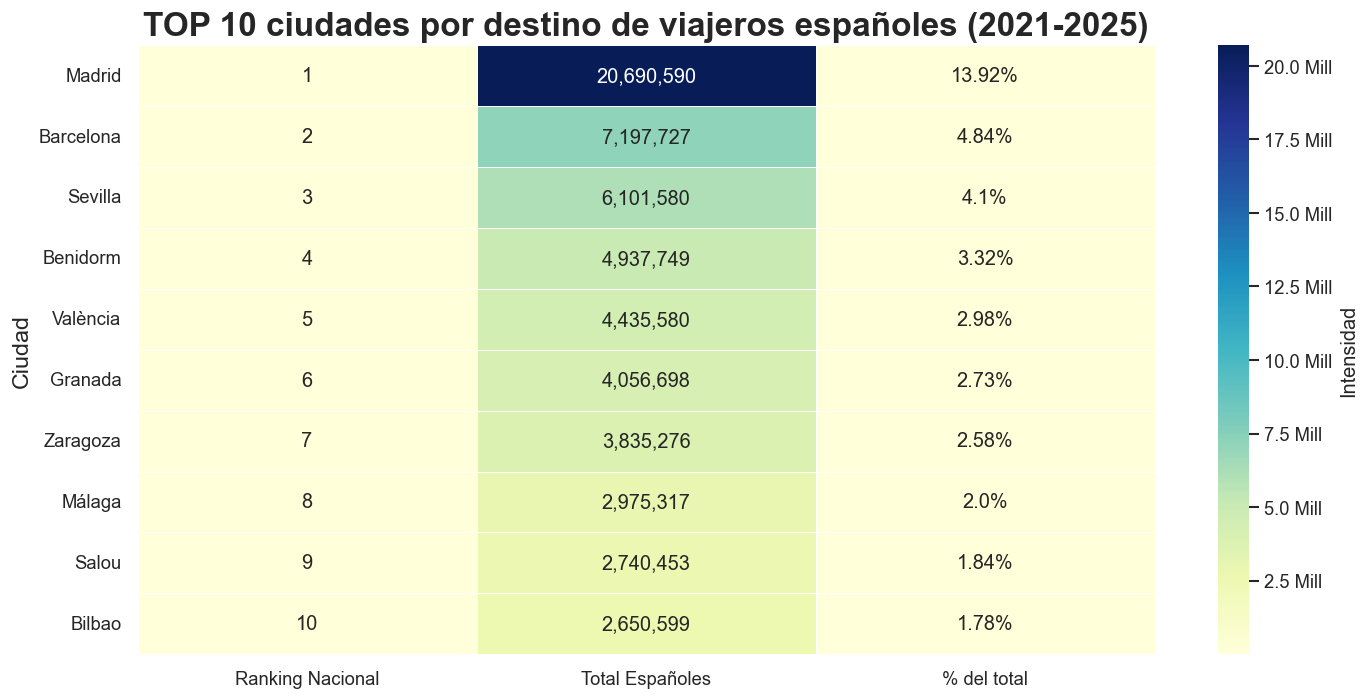

In [26]:
# Ordenar por total de españoles y quedarnos con el TOP 10
df_top10 = df_españoles_por_ciudad.sort_values('Total Españoles', ascending=False).head(10)

# ➜ Añadir columna de ranking nacional
df_top10['Ranking Nacional'] = range(1, len(df_top10) + 1)

# Crear copia para anotaciones formateadas
df_heatmap = df_top10.copy()

# Formatear TOTAL sin decimales y con separador de miles
df_heatmap['Total Españoles'] = df_heatmap['Total Españoles'].apply(lambda x: f"{x:,.0f}")

# Formatear porcentaje con decimales + símbolo %
df_heatmap['% del total'] = df_heatmap['% del total'].round(2).astype(str) + '%'

# Formatear ranking como texto
df_heatmap['Ranking Nacional'] = df_heatmap['Ranking Nacional'].astype(str)

# DataFrame numérico para el heatmap
df_numeric = df_top10[['Ranking Nacional', 'Total Españoles', '% del total']].copy()
df_numeric['% del total'] = df_top10['% del total']  # valores numéricos reales

# Crear figura
plt.figure(figsize=(12, 6))

# Heatmap con anotaciones personalizadas
sns.heatmap(
    df_numeric,
    annot=df_heatmap[['Ranking Nacional', 'Total Españoles', '% del total']],
    fmt="",
    cmap="YlGnBu",
    linewidths=.5,
    cbar_kws={'label': 'Intensidad'}
)

# Cambiar escala del colorbar a "Mill"
cbar = plt.gca().collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1_000_000:.1f} Mill"))

plt.title("TOP 10 ciudades por destino de viajeros españoles (2021-2025)", fontsize=20, fontweight='bold')
plt.xlabel("")
plt.ylabel("Ciudad", fontsize=14)

plt.tight_layout()
plt.show()


**Interpretación técnica:** La tabla muestra el TOP 10 de destinos del viajero español entre 2021 y 2025, ordenados por volumen total. Madrid destaca de forma contundente como el principal destino nacional, concentrando el 13,92% de todos los viajes de españoles en España. Barcelona (4,84%) y Sevilla (4,10%) ocupan las siguientes posiciones, aunque con una distancia considerable respecto a Madrid.
A partir del cuarto puesto, los porcentajes descienden de forma progresiva, con destinos turísticos como Benidorm, València o Salou alternándose con ciudades culturales como Granada, Zaragoza o Bilbao. La distribución muestra una curva de concentración muy pronunciada: el primer destino acumula casi la misma cuota que los puestos 2 al 4 combinados.
El ranking confirma que el viajero español combina turismo urbano (Madrid, Barcelona, Sevilla, Zaragoza, Bilbao) con turismo vacacional (Benidorm, Salou), lo que refleja un patrón diversificado pero claramente dominado por grandes núcleos urbanos.

**Interpretación de negocio:** El viajero español tiene una preferencia muy marcada por Madrid, lo que convierte a la capital en un destino estratégico para cualquier operador turístico que quiera maximizar captación nacional. Barcelona y Sevilla completan un bloque de ciudades clave donde la presencia de StaySpain tiene un impacto directo en volumen, visibilidad y retorno comercial.
La presencia de destinos vacacionales como Benidorm y Salou indica que el mercado nacional combina escapadas urbanas con turismo de sol y playa, lo que abre oportunidades para diversificar campañas según temporada.
Para StaySpain, este ranking confirma que su portfolio está bien alineado con los destinos más demandados por los españoles, lo que facilita la captación nacional sin necesidad de grandes esfuerzos de reposicionamiento.
La fuerte concentración en los primeros puestos sugiere que reforzar presencia, inversión y acciones comerciales en Madrid, Barcelona y Sevilla generará retornos desproporcionadamente altos. Al mismo tiempo, destinos como Granada, Zaragoza o Bilbao representan oportunidades de crecimiento incremental donde la competencia es menor y la demanda sigue siendo significativa.


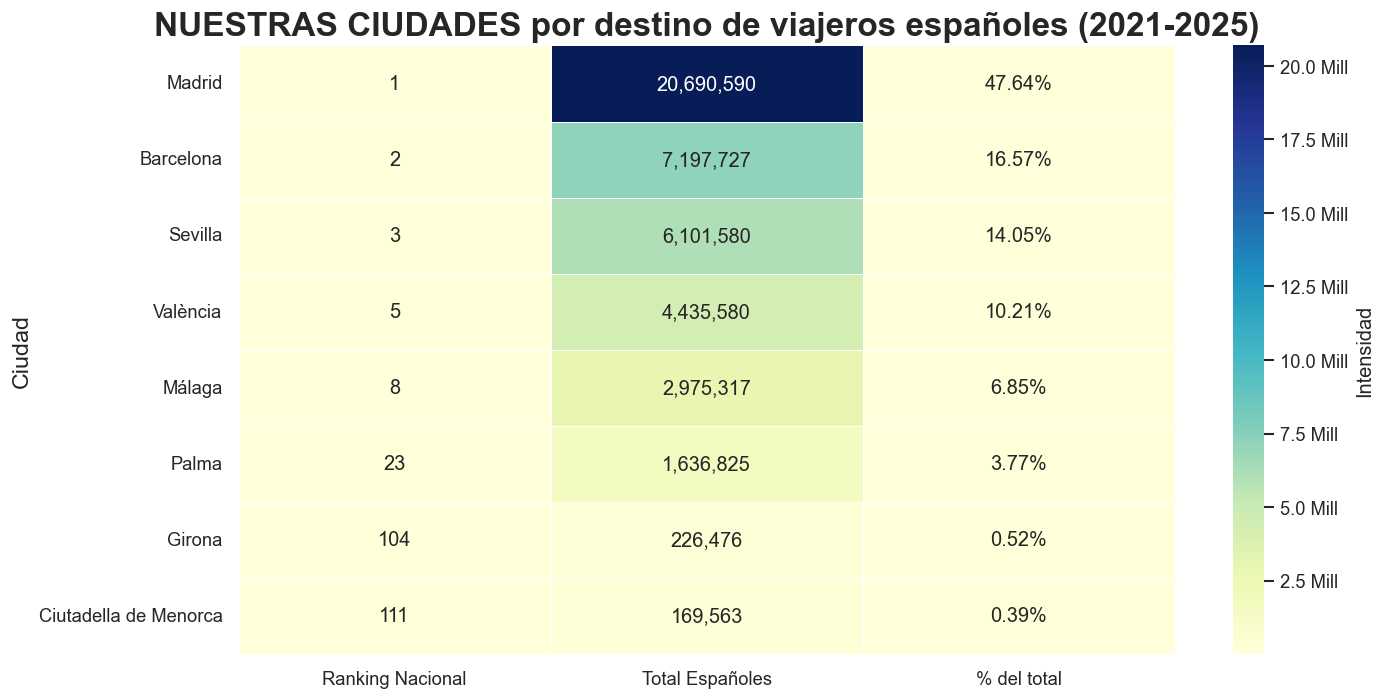

In [31]:
# TOP 10 ciudades (solo nuestras ciudades)
df_top10_es_mis = df_españoles_mis_ciudades.sort_values('Total Españoles', ascending=False).head(10)

# ➜ Añadir Ranking Nacional desde el DF nacional
df_top10_es_mis['Ranking Nacional'] = df_españoles_por_ciudad['Ranking Nacional']

# Copia para anotaciones formateadas
df_heatmap_es_mis = df_top10_es_mis.copy()

# Formatear TOTAL sin decimales y con separador de miles
df_heatmap_es_mis['Total Españoles'] = df_heatmap_es_mis['Total Españoles'].apply(lambda x: f"{x:,.0f}")

# Formatear porcentaje con decimales + símbolo %
df_heatmap_es_mis['% del total'] = df_heatmap_es_mis['% del total'].round(2).astype(str) + '%'

# Formatear ranking nacional como texto
df_heatmap_es_mis['Ranking Nacional'] = df_heatmap_es_mis['Ranking Nacional'].astype(int).astype(str)

# DataFrame numérico para el heatmap
df_numeric_es_mis = df_top10_es_mis[['Ranking Nacional', 'Total Españoles', '% del total']].copy()
df_numeric_es_mis['% del total'] = df_top10_es_mis['% del total']  # valores numéricos reales

# Crear figura
plt.figure(figsize=(12, 6))

# Heatmap con anotaciones personalizadas
sns.heatmap(
    df_numeric_es_mis,
    annot=df_heatmap_es_mis[['Ranking Nacional', 'Total Españoles', '% del total']],
    fmt="",
    cmap="YlGnBu",
    linewidths=.5,
    cbar_kws={'label': 'Intensidad'}
)

# Cambiar escala del colorbar a "Mill"
cbar = plt.gca().collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1_000_000:.1f} Mill"))

plt.title("NUESTRAS CIUDADES por destino de viajeros españoles (2021-2025)", fontsize=20, fontweight='bold')
plt.xlabel("")
plt.ylabel("Ciudad", fontsize=14)

plt.tight_layout()
plt.show()


**Interpretación técnica:** La tabla muestra cómo se comportan nuestras ciudades dentro del ranking nacional de destinos del viajero español entre 2021 y 2025. Madrid domina de forma absoluta, concentrando el 47,64% de todos los viajes nacionales que llegan a nuestras ciudades y ocupando el puesto 1 del ranking nacional. Barcelona (16,57%) y Sevilla (14,05%) completan un bloque de ciudades con un peso muy superior al resto.
A partir de la cuarta posición, la cuota desciende de forma progresiva: València (10,21%) y Málaga (6,85%) mantienen relevancia, mientras que Palma (3,77%) cae al puesto 23 del ranking general. Girona (0,52%) y Ciutadella (0,39%) aparecen muy abajo en el ranking (104 y 111), lo que indica un volumen reducido dentro del comportamiento del viajero español.
El patrón general muestra una altísima concentración: las tres primeras ciudades acumulan casi el 80% del total de viajeros españoles dentro de nuestro portfolio, lo que evidencia una distribución muy desigual y dominada por grandes núcleos urbanos.

**Interpretación de negocio:** Para StaySpain, este ranking confirma que el viajero español se concentra de forma masiva en tres destinos clave: Madrid, Barcelona y Sevilla. Estos mercados son estratégicos para maximizar captación nacional, ya que representan la mayor parte del volumen y del interés del público doméstico.
València y Málaga mantienen un peso relevante y estable, lo que las convierte en destinos secundarios pero sólidos dentro del mercado nacional. Palma, Girona y Ciutadella, en cambio, muestran un comportamiento mucho más nicho: su baja posición en el ranking indica que su potencial de crecimiento nacional es limitado y que su rol debe entenderse más como complemento que como motor de volumen.
La fuerte concentración en los primeros puestos implica que cualquier inversión comercial, de marketing o de expansión en Madrid, Barcelona y Sevilla tendrá un impacto directo y desproporcionadamente alto. Al mismo tiempo, los destinos de menor volumen pueden aprovecharse para estrategias específicas de diferenciación, estancias temáticas o productos de temporada.


# 4.- Destino del viajero extranjero

## 4.1.- Por ciudad Destino

In [75]:

# TOP 10 de la Suma de viajeros extranjeros por ciudad destino de toda España
suma_extranjeros_por_ciudad = (
    df_viajeros_total[
        df_viajeros_total['Residencia'] == 'Residentes en el Extranjero'
    ]
    .groupby('nombre_ciudad')['Total']
    .sum()
    .sort_values(ascending=False)
)

# Calcular el total nacional de extranjeros
total_españa_ext = suma_extranjeros_por_ciudad.sum()

# Crear DataFrame con porcentaje
df_extranjeros_por_ciudad = suma_extranjeros_por_ciudad.to_frame(name='Total Extranjeros')
df_extranjeros_por_ciudad['% del total'] = (
    df_extranjeros_por_ciudad['Total Extranjeros'] / total_españa_ext * 100
).round(2)

# Añadir columna de ranking nacional
df_extranjeros_por_ciudad['Ranking Nacional'] = range(1, len(df_extranjeros_por_ciudad) + 1)

# Mostrar TOP 10
print("=== TOP TEN DESTINOS DEL VIAJERO EXTRANJERO ===")
display(df_extranjeros_por_ciudad.head(10))


=== TOP TEN DESTINOS DEL VIAJERO EXTRANJERO ===


,Total Extranjeros,% del total,Ranking Nacional
nombre_ciudad,,,
Barcelona,29077399.0,15.58,1
Madrid,23325992.0,12.50,2
Palma,9531166.0,5.11,3
Sevilla,7280682.0,3.90,4
Calvià,6893695.0,3.69,5
San Bartolomé de Tirajana,6173167.0,3.31,6
Adeje,6162121.0,3.30,7
Benidorm,5126143.0,2.75,8
València,4920253.0,2.64,9


**Interpretación técnica:** La tabla muestra el TOP 10 de destinos del viajero extranjero en España entre 2021 y 2025. Barcelona encabeza el ranking con 15,58% del total de viajeros internacionales, seguida por Madrid con 12,50%. Ambas ciudades concentran casi un 28% del turismo extranjero, lo que evidencia una fuerte preferencia por grandes capitales urbanas.
A partir del tercer puesto, la distribución se diversifica hacia destinos de sol y playa: Palma (5,11%), Calvià (3,69%), San Bartolomé de Tirajana (3,31%) y Adeje (3,30%) muestran un patrón claro de atracción hacia las Islas Baleares y Canarias.
La presencia de Benidorm (2,75%), València (2,64%) y Málaga (2,21%) confirma que el turismo internacional combina destinos urbanos con destinos vacacionales. La curva de concentración es menos extrema que en el caso del viajero español, pero sigue mostrando un liderazgo claro de Barcelona y Madrid.

**Interpretación de negocio:** El viajero extranjero muestra una preferencia muy marcada por Barcelona y Madrid, lo que convierte a estas ciudades en los principales motores de captación internacional para StaySpain. La presencia dominante de Barcelona en el primer puesto indica que cualquier inversión en este destino tiene un impacto directo y significativo en el volumen internacional.
El peso de destinos de playa como Palma, Calvià, Adeje o San Bartolomé de Tirajana revela que el turismo internacional busca tanto experiencias urbanas como vacacionales. Esto abre oportunidades para StaySpain en la diversificación de producto: estancias urbanas premium, paquetes combinados ciudad‑playa y experiencias adaptadas a mercados emisores europeos.
La distribución más equilibrada en los puestos 3 al 10 sugiere que existe margen para crecer en destinos secundarios con alta demanda internacional, especialmente en Baleares, Canarias y la Costa Blanca.
En conjunto, este ranking confirma que el crecimiento internacional de StaySpain debe apoyarse en una estrategia dual: reforzar la presencia en Barcelona y Madrid, donde se concentra la mayor parte del volumen, y expandir oferta en destinos vacacionales donde la demanda extranjera es estable y menos sensible a la estacionalidad.


In [42]:
# Suma total de extranjeros por ciudad (toda España)
suma_extranjeros_por_ciudad = (
    df_viajeros_total[
        df_viajeros_total['Residencia'] == 'Residentes en el Extranjero'
    ]
    .groupby('nombre_ciudad')['Total']
    .sum()
    .sort_values(ascending=False)
)

# Total nacional de extranjeros
total_extranjeros_nacional = suma_extranjeros_por_ciudad.sum()

# Crear DF con total y porcentaje
df_extranjeros_por_ciudad = suma_extranjeros_por_ciudad.to_frame(name='Total Extranjeros')
df_extranjeros_por_ciudad['% del total'] = (
    df_extranjeros_por_ciudad['Total Extranjeros'] / total_extranjeros_nacional * 100
).round(2)

# Añadir ranking nacional
df_extranjeros_por_ciudad['Ranking Nacional'] = range(1, len(df_extranjeros_por_ciudad) + 1)


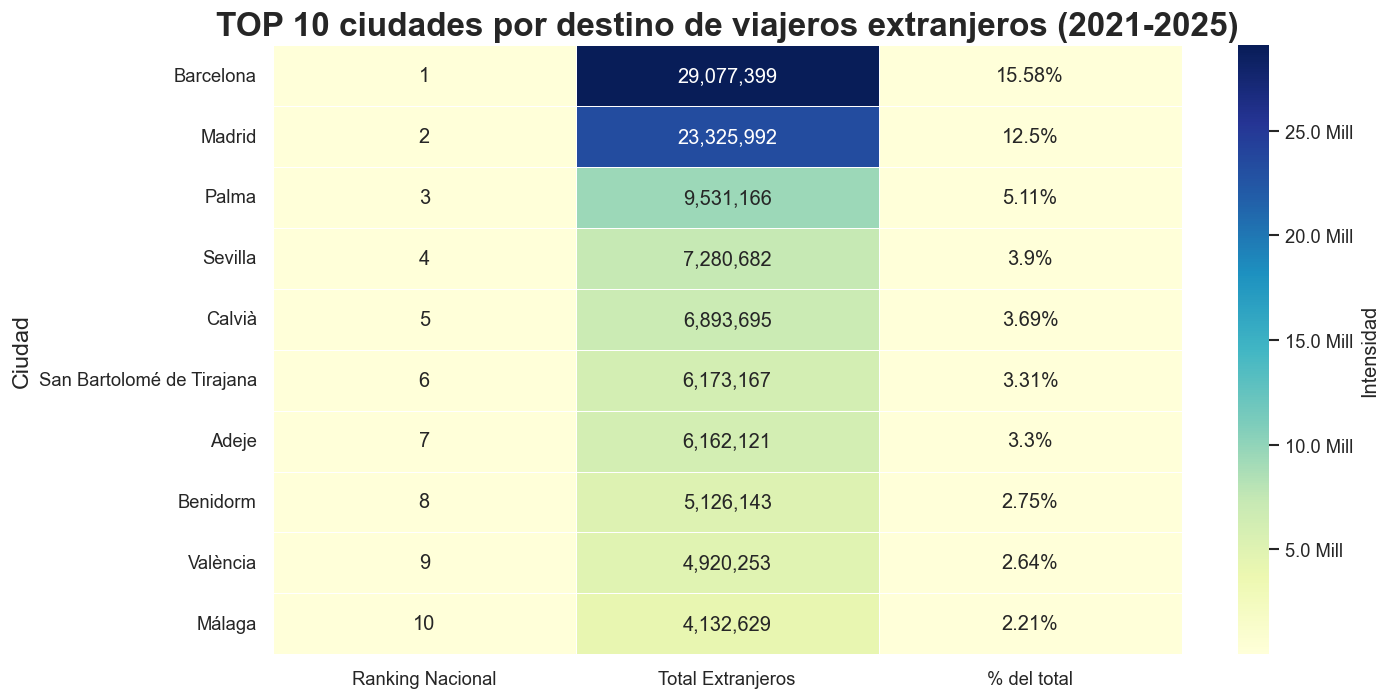

In [44]:
# TOP 10 ciudades (extranjeros)
df_top10_ext = df_extranjeros_por_ciudad.sort_values('Total Extranjeros', ascending=False).head(10)

# Añadir Ranking Nacional
df_top10_ext['Ranking Nacional'] = df_extranjeros_por_ciudad['Ranking Nacional']

# Copia para anotaciones formateadas
df_heatmap_ext = df_top10_ext.copy()

# Formatear TOTAL sin decimales y con separador de miles
df_heatmap_ext['Total Extranjeros'] = df_heatmap_ext['Total Extranjeros'].apply(lambda x: f"{x:,.0f}")

# Formatear porcentaje con decimales + símbolo %
df_heatmap_ext['% del total'] = df_heatmap_ext['% del total'].round(2).astype(str) + '%'

# Formatear ranking nacional como texto
df_heatmap_ext['Ranking Nacional'] = df_heatmap_ext['Ranking Nacional'].astype(int).astype(str)

# DataFrame numérico para el heatmap
df_numeric_ext = df_top10_ext[['Ranking Nacional', 'Total Extranjeros', '% del total']].copy()
df_numeric_ext['% del total'] = df_top10_ext['% del total']  # valores numéricos reales

# Crear figura
plt.figure(figsize=(12, 6))

# Heatmap con anotaciones personalizadas
sns.heatmap(
    df_numeric_ext,
    annot=df_heatmap_ext[['Ranking Nacional', 'Total Extranjeros', '% del total']],
    fmt="",
    cmap="YlGnBu",
    linewidths=.5,
    cbar_kws={'label': 'Intensidad'}
)

# Cambiar escala del colorbar a "Mill"
cbar = plt.gca().collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1_000_000:.1f} Mill"))

plt.title("TOP 10 ciudades por destino de viajeros extranjeros (2021-2025)", fontsize=20, fontweight='bold')
plt.xlabel("")
plt.ylabel("Ciudad", fontsize=14)

plt.tight_layout()
plt.show()


**Interpretación técnica:** La tabla muestra el TOP 10 de destinos del viajero extranjero en España entre 2021 y 2025. Barcelona lidera el ranking con 15,58% del total de viajeros internacionales, seguida por Madrid con 12,50%. Ambas ciudades concentran casi un 28% del turismo extranjero, lo que evidencia una fuerte preferencia por grandes capitales urbanas.
A partir del tercer puesto, la distribución se desplaza hacia destinos vacacionales: Palma (5,11%), Calvià (3,69%), San Bartolomé de Tirajana (3,31%) y Adeje (3,30%) muestran un patrón claro de atracción hacia Baleares y Canarias.
Benidorm (2,75%), València (2,64%) y Málaga (2,21%) completan el ranking, confirmando que el turismo internacional combina destinos urbanos con destinos de sol y playa. La curva de concentración es menos extrema que en el caso del viajero español, pero sigue mostrando un liderazgo claro de Barcelona y Madrid.

**Interpretación de negocio:** El viajero extranjero muestra una preferencia muy marcada por Barcelona y Madrid, lo que convierte a estas ciudades en los principales motores de captación internacional para StaySpain. La posición dominante de Barcelona implica que cualquier inversión en este destino tiene un impacto directo y significativo en el volumen internacional.
El peso de destinos de playa como Palma, Calvià, Adeje o San Bartolomé de Tirajana revela que el turismo internacional busca tanto experiencias urbanas como vacacionales. Esto abre oportunidades para StaySpain en la diversificación de producto: estancias urbanas premium, paquetes combinados ciudad‑playa y experiencias adaptadas a mercados emisores europeos.
La distribución más equilibrada en los puestos 3 al 10 sugiere que existe margen para crecer en destinos secundarios con alta demanda internacional, especialmente en Baleares, Canarias y la Costa Blanca.
En conjunto, este ranking confirma que el crecimiento internacional de StaySpain debe apoyarse en una estrategia dual: reforzar la presencia en Barcelona y Madrid, donde se concentra la mayor parte del volumen, y expandir oferta en destinos vacacionales donde la demanda extranjera es estable y menos sensible a la estacionalidad. 


In [76]:
# Suma de viajeros extranjeros que visitan nuestras ciudades
suma_extranjeros_mis_ciudades = (
    df_viajeros_mis_ciudades[
        df_viajeros_mis_ciudades['Residencia'] == 'Residentes en el Extranjero'
    ]
    .groupby('nombre_ciudad')['Total']
    .sum()
    .sort_values(ascending=False)
)

# Total de extranjeros que visitan nuestras ciudades
total_extranjeros = suma_extranjeros_mis_ciudades.sum()

# Crear DataFrame con porcentaje
df_extranjeros_mis_ciudades = suma_extranjeros_mis_ciudades.to_frame(name='Total Extranjeros')
df_extranjeros_mis_ciudades['% del total'] = (
    df_extranjeros_mis_ciudades['Total Extranjeros'] / total_extranjeros * 100
).round(2)

# ➜ Añadir Ranking Nacional desde el DF nacional
df_extranjeros_mis_ciudades = df_extranjeros_mis_ciudades.merge(
    df_extranjeros_por_ciudad[['Ranking Nacional']],
    left_index=True,
    right_index=True,
    how='left'
)

print("=== NUESTRAS CIUDADES COMO DESTINOS DEL VIAJERO EXTRANJERO ===")
display(df_extranjeros_mis_ciudades)


=== NUESTRAS CIUDADES COMO DESTINOS DEL VIAJERO EXTRANJERO ===


,Total Extranjeros,% del total,Ranking Nacional
nombre_ciudad,,,
Barcelona,29077399.0,36.71,1
Madrid,23325992.0,29.45,2
Palma,9531166.0,12.03,3
Sevilla,7280682.0,9.19,4
València,4920253.0,6.21,9
Málaga,4132629.0,5.22,10
Ciutadella de Menorca,561701.0,0.71,51
Girona,385685.0,0.49,68


**Interpretación técnica:** La tabla muestra cómo se comportan nuestras ciudades dentro del ranking nacional de destinos del viajero extranjero entre 2021 y 2025. Barcelona lidera de forma clara, concentrando el 36,71% de todos los viajeros internacionales que llegan a nuestras ciudades y ocupando el puesto 1 del ranking nacional. Madrid (29,45%) se sitúa en segunda posición, formando junto a Barcelona un bloque que acumula dos tercios del total internacional.
A partir de la tercera posición, la cuota desciende de forma progresiva: Palma (12,03%) y Sevilla (9,19%) mantienen un peso relevante, mientras que València (6,21%) y Málaga (5,22%) completan el grupo de ciudades con volumen significativo. Ciutadella (0,71%) y Girona (0,49%) aparecen muy abajo en el ranking (51 y 68), lo que indica un volumen reducido dentro del comportamiento del viajero extranjero.
El patrón general muestra una concentración muy elevada: las dos primeras ciudades acumulan más del 66% del total, lo que evidencia una distribución dominada por grandes capitales urbanas y destinos insulares de alta demanda internacional.

**Interpretación de negocio:** Para StaySpain, este ranking confirma que el viajero extranjero se concentra de forma masiva en Barcelona y Madrid, que son los principales motores de captación internacional. Cualquier inversión en estos destinos tiene un impacto directo y desproporcionadamente alto en volumen, visibilidad y retorno.
Palma y Sevilla representan destinos estratégicos secundarios, con una demanda internacional sólida y estable, especialmente atractiva para mercados europeos. València y Málaga mantienen un peso relevante y permiten diversificar la oferta hacia modelos mixtos de turismo urbano y vacacional.
Ciutadella y Girona, con cuotas muy bajas, deben entenderse como destinos nicho: su potencial internacional es limitado, pero pueden aportar valor en estrategias específicas de temporada, producto diferenciado o mercados concretos.
La fuerte concentración en los primeros puestos implica que la estrategia internacional de StaySpain debe ser dual: reforzar la presencia en Barcelona y Madrid, donde se concentra la mayor parte del volumen, y expandir oferta en destinos insulares y mediterráneos donde la demanda extranjera es estable, menos estacional y con mayor gasto medio.


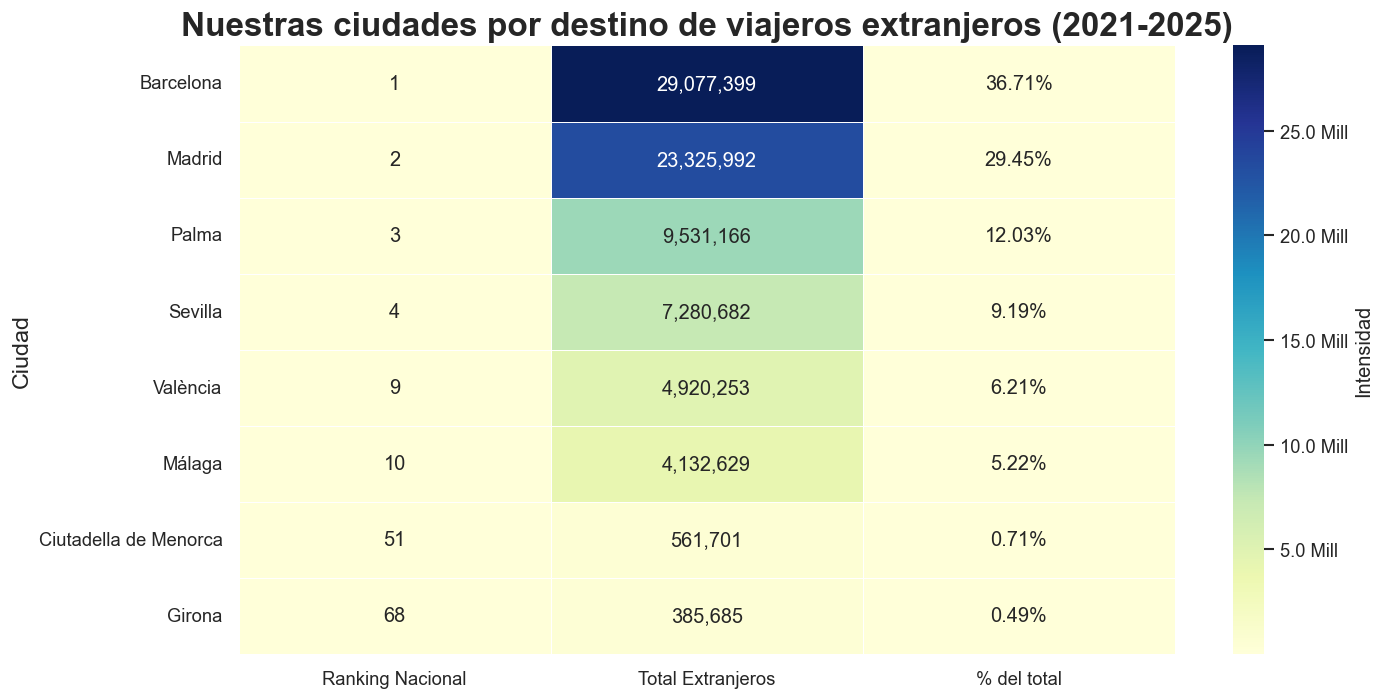

In [48]:
# TOP 10 ciudades (solo nuestras ciudades, extranjeros)
df_top10_ext_mis = df_extranjeros_mis_ciudades.sort_values('Total Extranjeros', ascending=False).head(10)

# Copia para anotaciones formateadas
df_heatmap_ext_mis = df_top10_ext_mis.copy()

# Formatear TOTAL sin decimales y con separador de miles
df_heatmap_ext_mis['Total Extranjeros'] = df_heatmap_ext_mis['Total Extranjeros'].apply(lambda x: f"{x:,.0f}")

# Formatear porcentaje con decimales + símbolo %
df_heatmap_ext_mis['% del total'] = df_heatmap_ext_mis['% del total'].round(2).astype(str) + '%'

# Formatear ranking nacional como texto
df_heatmap_ext_mis['Ranking Nacional'] = df_heatmap_ext_mis['Ranking Nacional'].astype(int).astype(str)

# DataFrame numérico para el heatmap
df_numeric_ext_mis = df_top10_ext_mis[['Ranking Nacional', 'Total Extranjeros', '% del total']].copy()
df_numeric_ext_mis['% del total'] = df_top10_ext_mis['% del total']  # valores numéricos reales

# Crear figura
plt.figure(figsize=(12, 6))

# Heatmap con anotaciones personalizadas
sns.heatmap(
    df_numeric_ext_mis,
    annot=df_heatmap_ext_mis[['Ranking Nacional', 'Total Extranjeros', '% del total']],
    fmt="",
    cmap="YlGnBu",
    linewidths=.5,
    cbar_kws={'label': 'Intensidad'}
)

# Cambiar escala del colorbar a "Mill"
cbar = plt.gca().collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1_000_000:.1f} Mill"))

plt.title("Nuestras ciudades por destino de viajeros extranjeros (2021-2025)", fontsize=20, fontweight='bold')
plt.xlabel("")
plt.ylabel("Ciudad", fontsize=14)

plt.tight_layout()
plt.show()


**Interpretación técnica:** La tabla muestra cómo se comportan nuestras ciudades dentro del ranking nacional de destinos del viajero extranjero entre 2021 y 2025. Barcelona lidera de forma contundente, concentrando el 36,71% de todos los viajeros internacionales que llegan a nuestras ciudades y ocupando el puesto 1 del ranking nacional. Madrid (29,45%) se sitúa en segunda posición, formando junto a Barcelona un bloque que acumula más de dos tercios del total internacional.
A partir de la tercera posición, la cuota desciende de forma progresiva: Palma (12,03%) y Sevilla (9,19%) mantienen un peso relevante, mientras que València (6,21%) y Málaga (5,22%) completan el grupo de ciudades con volumen significativo.
Ciutadella (0,71%) y Girona (0,49%) aparecen muy abajo en el ranking (51 y 68), lo que indica un volumen reducido dentro del comportamiento del viajero extranjero.
El patrón general muestra una concentración muy elevada: las dos primeras ciudades acumulan más del 66% del total, lo que evidencia una distribución dominada por grandes capitales urbanas y destinos insulares de alta demanda internacional.

**Interpretación de negocio:** Para StaySpain, este ranking confirma que el viajero extranjero se concentra de forma masiva en Barcelona y Madrid, que son los principales motores de captación internacional. Cualquier inversión en estos destinos tiene un impacto directo y desproporcionadamente alto en volumen, visibilidad y retorno.
Palma y Sevilla representan destinos estratégicos secundarios, con una demanda internacional sólida y estable, especialmente atractiva para mercados europeos. València y Málaga permiten diversificar la oferta hacia modelos mixtos de turismo urbano y vacacional, manteniendo un flujo internacional relevante.
Ciutadella y Girona, con cuotas muy bajas, deben entenderse como destinos nicho: su potencial internacional es limitado, pero pueden aportar valor en estrategias específicas de temporada, producto diferenciado o mercados concretos.
La fuerte concentración en los primeros puestos implica que la estrategia internacional de StaySpain debe ser dual: reforzar la presencia en Barcelona y Madrid, donde se concentra la mayor parte del volumen, y expandir oferta en destinos insulares y mediterráneos, donde la demanda extranjera es estable, menos estacional y con mayor gasto medio.


## 4.2.- Por ciudad Origen

In [50]:
df_residencias

,RESIDENCIA/ORIGEN,Países,Viajeros y pernoctaciones,Periodo,Total,año,mes
0,Total,NaN,Viajero,2025M12,6937385.0,2025,12
1,Total,NaN,Viajero,2025M11,7413495.0,2025,11
2,Total,NaN,Viajero,2025M10,11041430.0,2025,10
3,Total,NaN,Viajero,2025M09,12050972.0,2025,9
4,Total,NaN,Viajero,2025M08,13828672.0,2025,8
...,...,...,...,...,...,...,...
3835,Asia (sin Japón),NaN,Pernoctaciones,2021M05,NaN,2021,5
3836,Asia (sin Japón),NaN,Pernoctaciones,2021M04,NaN,2021,4
3837,Asia (sin Japón),NaN,Pernoctaciones,2021M03,NaN,2021,3
3838,Asia (sin Japón),NaN,Pernoctaciones,2021M02,NaN,2021,2


In [53]:
df_residencias['RESIDENCIA/ORIGEN'].unique()

array(['Total', 'América (sin EEUU)', 'Estados Unidos de América',
       'Japón', 'Asia (sin Japón)'], dtype=object)

In [52]:
df_residencias['Países'].unique()

array([nan, 'Residentes en España', 'Residentes en el Extranjero',
       'Alemania', 'Austria', 'Bélgica', 'Dinamarca', 'Finlandia',
       'Francia', 'Grecia', 'Irlanda', 'Italia', 'Luxemburgo',
       'Países Bajos', 'Polonia', 'Portugal', 'República Checa', 'Suecia',
       'Resto de la U.E.', 'Noruega', 'Reino Unido', 'Rusia', 'Suiza',
       'Otros Países Europeos', 'África', 'UE28 sin España',
       'UE27_2020 sin España', 'Resto del Mundo'], dtype=object)

In [70]:
# Lista de valores a excluir
excluir = [
    'Residentes en España',
    'Residentes en el Extranjero',
    'UE28 sin España',
    'UE27_2020 sin España',
    'Resto de la U.E.'
]

# Filtrar solo viajeros
df_viajeros = df_residencias[df_residencias['Viajeros y pernoctaciones'] == 'Viajero']

# Filtrar solo países reales (Países no nulo)
df_viajeros = df_viajeros[df_viajeros['Países'].notna()]

# Excluir categorías no deseadas
df_viajeros = df_viajeros[~df_viajeros['Países'].isin(excluir)]

# Agrupar por país y sumar viajeros
ranking_paises = (
    df_viajeros
    .groupby('Países')['Total']
    .sum()
    .sort_values(ascending=False)
    .to_frame(name='Total Viajeros')
)

# Añadir ranking
ranking_paises['Ranking'] = range(1, len(ranking_paises) + 1)

print("=== PAISES ORIGEN DE VISITANTES ===")
display(ranking_paises.head(20))


=== PAISES ORIGEN DE VISITANTES ===


,Total Viajeros,Ranking
Países,,
Reino Unido,45910771.0,1
Alemania,32099411.0,2
Francia,28855587.0,3
Italia,14106507.0,4
Resto del Mundo,13174809.0,5
Países Bajos,11120104.0,6
Portugal,9032776.0,7
Otros Países Europeos,7577590.0,8
Bélgica,6703490.0,9


**Interpretación técnica:** La tabla muestra el ranking de países emisores de viajeros hacia España entre 2021 y 2025. Reino Unido lidera con 45,9 millones de viajeros, seguido por Alemania (32,1 M) y Francia (28,9 M). Estos tres países concentran una parte muy significativa del total internacional, lo que evidencia una fuerte dependencia de los mercados europeos tradicionales.
Italia (14,1 M) y el grupo “Resto del Mundo” (13,1 M) ocupan posiciones intermedias, mientras que Países Bajos, Portugal y Bélgica mantienen volúmenes relevantes entre los 6 y 11 millones.
A partir de la décima posición, los volúmenes descienden de forma progresiva, aunque siguen siendo significativos: Irlanda, Polonia, Suiza y Suecia superan los 3,7 millones. Los países nórdicos (Suecia, Dinamarca, Noruega, Finlandia) aparecen de forma consistente, lo que confirma su peso como mercados emisores estables.
El patrón general muestra una curva de concentración moderada: los tres primeros países aportan más de 100 millones de viajeros, pero existe una larga cola de mercados secundarios que, en conjunto, suman un volumen considerable.

**Interpretación de negocio:** Para StaySpain, este ranking confirma que el turismo internacional en España depende principalmente de Reino Unido, Alemania y Francia, que deben considerarse mercados prioritarios en cualquier estrategia de captación, pricing y comunicación. Son mercados maduros, con alta conectividad aérea y una demanda estable incluso en contextos económicos adversos.
Italia, Países Bajos, Portugal y Bélgica representan mercados secundarios de alto potencial, ideales para campañas específicas, optimización de rutas aéreas y productos adaptados a estancias cortas y escapadas urbanas.
Los países nórdicos, aunque con menor volumen individual, destacan por su alto gasto medio, lo que los convierte en mercados estratégicos para productos premium, estancias largas y experiencias de mayor valor añadido.
El grupo “Resto del Mundo” muestra que existe una base creciente de viajeros extracomunitarios, especialmente de América y Asia, que pueden impulsar el crecimiento futuro si se refuerzan las conexiones internacionales y la presencia en OTAs globales.
En conjunto, este ranking permite a StaySpain priorizar esfuerzos:
 - Mercados core: Reino Unido, Alemania, Francia.
 - Mercados de crecimiento: Italia, Países Bajos, Bélgica, Portugal.
 - Mercados de alto valor: Países nórdicos, Suiza.
 - Mercados emergentes: Resto del Mundo.


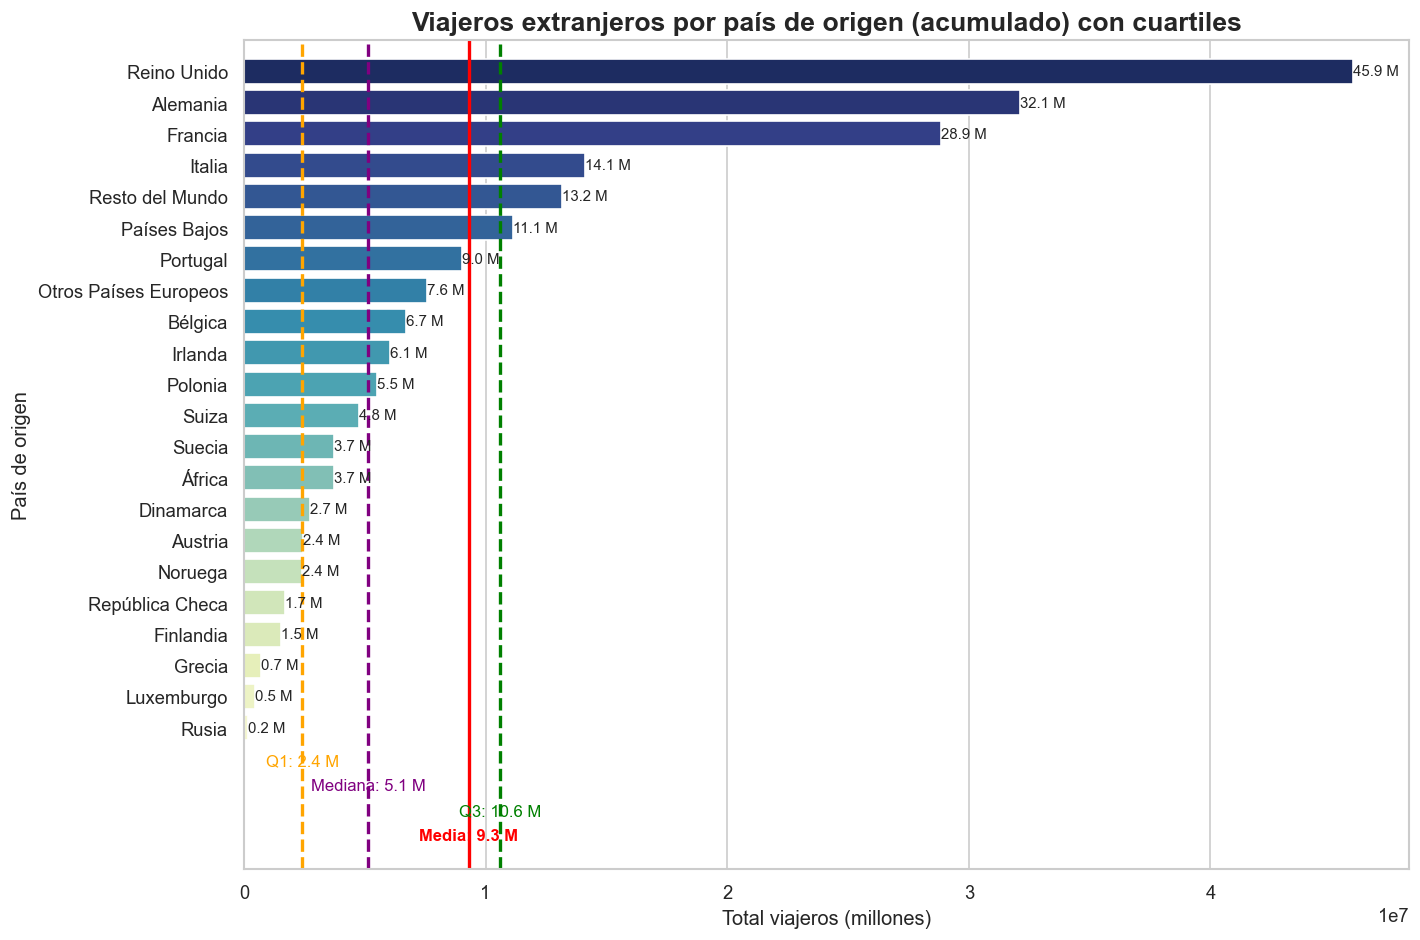

In [69]:
df_plot = ranking_paises.reset_index().copy()
df_plot = df_plot.sort_values('Total Viajeros', ascending=True)

plt.figure(figsize=(12, 8))
sns.barplot(
    data=df_plot,
    x='Total Viajeros',
    y='Países',
    palette='YlGnBu'
)

# Etiquetas en millones
for i, v in enumerate(df_plot['Total Viajeros']):
    plt.text(v, i, f"{v/1_000_000:.1f} M", va='center', ha='left', fontsize=9)

# Cuartiles y media
q1 = df_plot['Total Viajeros'].quantile(0.25)
q2 = df_plot['Total Viajeros'].quantile(0.50)
q3 = df_plot['Total Viajeros'].quantile(0.75)
media = df_plot['Total Viajeros'].mean()

# Líneas verticales
plt.axvline(q1, color='orange', linestyle='--', linewidth=2)
plt.axvline(q2, color='purple', linestyle='--', linewidth=2)
plt.axvline(q3, color='green', linestyle='--', linewidth=2)
plt.axvline(media, color='red', linestyle='-', linewidth=2)

# ➜ Crear espacio real debajo del eje X
plt.ylim(-4.5, len(df_plot))   # más espacio inferior

# ➜ Etiquetas en niveles distintos
plt.text(q1,   -1.2, f"Q1: {q1/1_000_000:.1f} M", color='orange', ha='center', fontsize=10)
plt.text(q2,   -2.0, f"Mediana: {q2/1_000_000:.1f} M", color='purple', ha='center', fontsize=10)
plt.text(q3,   -2.8, f"Q3: {q3/1_000_000:.1f} M", color='green', ha='center', fontsize=10)
plt.text(media,-3.6, f"Media: {media/1_000_000:.1f} M", color='red', ha='center', fontsize=10, fontweight='bold')

plt.title("Viajeros extranjeros por país de origen (acumulado) con cuartiles", fontsize=16, fontweight='bold')
plt.xlabel("Total viajeros (millones)")
plt.ylabel("País de origen")

plt.tight_layout()
plt.show()


**Interpretación técnica:** El gráfico muestra el volumen acumulado de viajeros extranjeros por país de origen, acompañado de líneas de cuartiles y medidas estadísticas que permiten entender la distribución. Reino Unido (45,9 M), Alemania (32,1 M) y Francia (28,9 M) destacan claramente por encima del resto, situándose muy por encima de la media (9,3 M) y del tercer cuartil (10,6 M).
Italia (14,1 M) y el grupo “Resto del Mundo” (13,2 M) se sitúan entre la mediana (5,1 M) y el Q3, lo que indica que forman parte del segmento superior pero sin llegar al nivel de los tres mercados principales.
La mayoría de países se concentran entre Q1 (2,4 M) y la mediana, lo que refleja una larga cola de mercados secundarios con volúmenes relevantes pero mucho más bajos. Países nórdicos, Suiza, Polonia e Irlanda se agrupan en este tramo intermedio.
Los países por debajo de Q1 (como Grecia, Luxemburgo o Rusia) representan mercados marginales en términos de volumen, aunque pueden tener comportamientos estacionales o nicho.

**Interpretación de negocio:** El análisis confirma que el turismo internacional en España depende de forma muy significativa de Reino Unido, Alemania y Francia, que deben considerarse mercados absolutamente prioritarios para StaySpain. Son mercados maduros, con alta conectividad aérea y una demanda estable que sostiene el volumen anual.
Italia, Países Bajos, Portugal y Bélgica forman un bloque de mercados secundarios con alto potencial, ideales para campañas específicas, acuerdos con aerolíneas y estrategias de captación orientadas a escapadas urbanas y city breaks.
Los países nórdicos, Suiza e Irlanda, aunque con menor volumen, destacan por su alto gasto medio, lo que los convierte en mercados estratégicos para productos premium, estancias largas y experiencias de mayor valor añadido.
El grupo “Resto del Mundo” muestra que existe una base creciente de viajeros extracomunitarios —especialmente de América y Asia— que pueden impulsar el crecimiento futuro si se refuerzan las conexiones internacionales y la presencia en OTAs globales.
En conjunto, esta distribución permite a StaySpain priorizar esfuerzos de forma clara:
 - Mercados core: Reino Unido, Alemania, Francia.
 - Mercados de crecimiento: Italia, Países Bajos, Portugal, Bélgica.
 - Mercados de alto valor: Países nórdicos, Suiza, Irlanda.
 - Mercados emergentes: Resto del Mundo.


# 5.- Limitaciones

Al analizar las fuentes y la estructura de los ficheros, se confirma esta LIMITACION que no se puede asociar pais origen con ciudad visitada:
 - Tabla de Residencia: Según los campos que has identificado (RESIDENCIA/ORIGEN, Países, Total), esta tabla ofrece datos agregados a nivel nacional
. Te dice cuántos portugueses han venido a España en total, pero no desglosa en qué provincia o ciudad se han quedado
.
 - Tabla de Puntos Turísticos: Esta tabla llega al detalle de la ciudad (nombre_ciudad), pero agrupa a todos los extranjeros bajo la etiqueta genérica de "Residente en el extranjero" en el campo Residencia, sin especificar el país de origen
  - No existe un campo "llave" (como un código de provincia o ciudad) que aparezca en ambos ficheros para unirlos.

# 6.- Principales hallazgos

1️⃣ **El turismo internacional está extremadamente concentrado en pocas ciudades**

**Hallazgo técnico:**  
Barcelona y Madrid concentran más del 66% de todos los viajeros extranjeros. Palma, Sevilla, València y Málaga forman un segundo bloque relevante, mientras que el resto de ciudades aportan volúmenes marginales.

**Implicación de negocio:**  
StaySpain debe priorizar inversión, captación y producto en Barcelona y Madrid como motores principales, y reforzar presencia en Baleares, Canarias y Andalucía como destinos vacacionales de alta demanda internacional.

2️⃣ **Los mercados emisores clave son Reino Unido, Alemania y Francia**

**Hallazgo técnico:**  
Estos tres países aportan más de 100 millones de viajeros, situándose muy por encima de la media y del tercer cuartil. Italia, Países Bajos, Portugal y Bélgica forman el grupo secundario de mayor volumen.

**Implicación de negocio**:**  
La estrategia internacional debe centrarse en:

 - Mercados core: Reino Unido, Alemania, Francia

 - Mercados de crecimiento: Italia, Países Bajos, Portugal, Bélgica

 - Mercados de alto valor: Países nórdicos y Suiza

 - Mercados emergentes: América y Asia (Resto del Mundo)

3️⃣ **El turismo extranjero supera al nacional en volumen y estacionalidad**

**Hallazgo técnico:**  
La serie de extranjeros es consistentemente superior a la de españoles durante todo el año. Ambos muestran estacionalidad, pero los extranjeros alcanzan su pico en agosto, mientras que los españoles lo hacen antes (junio–julio).

**Implicación de negocio:**

 - El verano debe orientarse a mercados internacionales con productos de larga estancia.

 - La primavera y principios de verano son clave para el mercado nacional (escapadas, city breaks).

 - Oportunidad clara para estrategias antiestacionalidad en otoño e invierno.

4️⃣ **Las ciudades turísticas muestran patrones diferenciados según tipo de viajero**

**Hallazgo técnico:**

 - Las grandes capitales (Barcelona, Madrid) atraen tanto a nacionales como a extranjeros, pero con mayor peso internacional.

 - Los destinos de playa (Palma, Calvià, Adeje, San Bartolomé) dependen fuertemente del turismo extranjero.

 - Ciudades medianas (València, Málaga) combinan ambos perfiles con equilibrio.

**Implicación de negocio:**  
StaySpain puede segmentar su oferta:

 - Urbano premium → Barcelona, Madrid

 - Vacacional internacional → Baleares, Canarias

 - Mixto urbano-playa → València, Málaga

 - Nicho estacional → Ciutadella, Girona

**5️⃣ La distribución de viajeros por país muestra una larga cola de mercados secundarios**

**Hallazgo técnico:**  
Aunque los tres primeros países dominan, existe una larga cola de mercados con volúmenes entre 1 y 10 millones (Irlanda, Polonia, Suiza, Suecia, Dinamarca, Austria…).
Estos mercados están por encima del primer cuartil y aportan volumen estable.

**Implicación de negocio:**

 - Son ideales para campañas específicas, acuerdos con aerolíneas y estrategias de diversificación.

 - Muchos de ellos (nórdicos, Suiza) tienen alto gasto medio, lo que permite productos premium y estancias largas.

# 7.- Recomendaciones de negocio para StaySpain

**Ordenadas por impacto potencial y urgencia estratégica:**

**🥇 1. Reforzar la presencia y el inventario en Barcelona y Madrid**

**Por qué es prioritario:** concentran **más del 66%** de todos los viajeros extranjeros.

**Qué hacer:**

 - Optimizar precios dinámicos en picos internacionales.

 - Aumentar disponibilidad y variedad de alojamientos.

 - Mejorar posicionamiento en OTAs y metabuscadores.

 - Activar campañas específicas para mercados core (UK, DE, FR).

**Impacto esperado:** máximo retorno por volumen, visibilidad y conversión.

**🥈 2. Potenciar mercados emisores core y secundarios de crecimiento**

**Por qué es prioritario:** Reino Unido, Alemania y Francia aportan más de **100 millones** de viajeros; Italia, Países Bajos, Portugal y Bélgica son mercados en expansión.

**Qué hacer:**

 - Campañas segmentadas por país.

 - Acuerdos con aerolíneas y OTAs internacionales.

 - Contenido y atención en idiomas clave.

 - Estrategias de retargeting por comportamiento.

**Impacto esperado:** crecimiento sostenido del flujo internacional y mayor estabilidad anual.

**🥉 3. Reducir la estacionalidad con productos y campañas anti‑invierno**

**Por qué es prioritario:** el turismo extranjero y nacional cae drásticamente de septiembre a diciembre.

**Qué hacer:**

 - Promover city breaks en Madrid, Barcelona, Sevilla y Málaga.

 - Activar campañas culturales, gastronómicas y de eventos.

 - Ofertas específicas para mercados con baja sensibilidad climática (nórdicos, Suiza).

 - Paquetes combinados ciudad + experiencia.

**Impacto esperado:** aumento de ocupación en temporada baja y mayor estabilidad de ingresos.

**🏅 4. Expandir oferta en destinos vacacionales de alta demanda internacional**

**Por qué es prioritario:** Palma, Calvià, Adeje y San Bartolomé concentran gran parte del turismo extranjero estival.

**Qué hacer:**

 - Incrementar inventario en Baleares y Canarias.

 - Crear productos de larga estancia para mercados UK, DE y NL.

 - Optimizar precios en julio–agosto.

 - Diferenciar oferta premium para mercados de alto valor (nórdicos).

**Impacto esperado:** maximizar ingresos en verano y aumentar ticket medio.

**🎯 Resumen ejecutivo (StaySpain en 4 movimientos)**

1. Dominar Barcelona y Madrid para capturar el grueso del turismo internacional.

2. Acelerar mercados emisores clave para asegurar crecimiento sostenido.

3. Combatir la estacionalidad con campañas y productos anti‑invierno.

4. Optimizar destinos vacacionales para maximizar ingresos en verano.
